Loading data

In [2]:
import os, math, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
try:
    import pandas as pd
except Exception:
    !pip -q install pandas
    import pandas as pd
import numpy as np
import nibabel as nib
from nilearn.image import resample_to_img
from skimage.segmentation import find_boundaries
from scipy.ndimage import distance_transform_edt
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr


from skimage import io, color, filters
from skimage.feature import canny, graycomatrix, graycoprops
from skimage.measure import shannon_entropy
from skimage.util import img_as_ubyte
import cv2


from scipy.ndimage import gaussian_filter, laplace
from skimage.feature import canny, graycomatrix, graycoprops
from skimage.measure import shannon_entropy
from skimage.util import img_as_ubyte



Define the metrics

In [3]:

def dice_coef(a, b):
    #TO-DO: write this func
    #dice_c = 2 * (a & b).sum() / (a.sum() + b.sum())
    intersect = np.sum(b*a)
    total_sum = np.sum(a) + np.sum(b)
    dice_c = np.mean(2*intersect / total_sum)

    return dice_c

def jaccard_iou(a, b):
    #TO-DO: write this func
    intersect = np.sum(b*a)
    union = np.sum(a) + np.sum(b) - intersect
    iou = np.mean(intersect / union)
    return iou


def precision(a, b):
    # a = prediction, b = reference
    #TO-DO: write this func
    intersect = np.sum(b*a)
    total_pixel_pred = np.sum(a)
    precision = np.mean(intersect / total_pixel_pred)
    return round(precision,3)


def recall(a, b):
    #TO-DO: write this func
    intersect = np.sum(b*a)
    total_pixel_ref = np.sum(b)
    recall = np.mean(intersect / total_pixel_ref)
    return round(recall,3)

def f1Score(a, b):
    prec = round(precision(a, b), 3)
    reca = round(recall(a, b), 3)
    f1_score = 2 * prec * reca / (prec + reca)
    return round(f1_score,3)

def surface_distances(a, b):
    """
    Compute symmetric surface distances between binary masks a (pred) and b (ref).
    Returns ASSD (average symmetric surface distance), Hausdorff, Hausdorff95.
    """
    a = a.astype(bool); b = b.astype(bool)
    if a.sum()==0 or b.sum()==0:
        return np.inf, np.inf, np.inf

    # surfaces
    a_bd = find_boundaries(a, mode='outer')
    b_bd = find_boundaries(b, mode='outer')

    # distance maps to the opposite surface
    # distance inside the complement gives distance to nearest True boundary
    dt_a = distance_transform_edt(~a_bd)
    dt_b = distance_transform_edt(~b_bd)

    # distances from each surface pixel in A to B and vice versa
    d_a2b = dt_b[a_bd]
    d_b2a = dt_a[b_bd]

    # symmetric set of distances
    all_d = np.concatenate([d_a2b, d_b2a]).astype(np.float64)
    if all_d.size == 0:
        return 0.0, 0.0, 0.0

    assd = all_d.mean()
    hd = all_d.max()
    #TO-DO: 95th percentile
    hd95 = np.percentile(all_d, 95)

    return assd, hd, hd95


# -----------------------
# Evaluating
# -----------------------
def eval_metrics(pred, ref):
    return {
        "Dice": dice_coef(pred, ref),
        "IoU": jaccard_iou(pred, ref),
        "Precision": precision(pred, ref),
        "Recall": recall(pred, ref),
        "F1 Score": f1Score(pred, ref),
        **(lambda a: {"ASSD": a[0], "HD": a[1], "HD95": a[2]})(surface_distances(pred, ref))
    }

def evaluate_and_print(pred, ref, name):
    d = dice_coef(pred, ref)
    j = jaccard_iou(pred, ref)
    p = precision(pred, ref)
    r = recall(pred, ref)
    f1 = f1Score(pred, ref),
    assd, hd, hd95 = surface_distances(pred, ref)
    print(f"[{name}] vs {GT_SRC}")
    print(f"  Dice: {d:.4f} | IoU: {j:.4f} | Precision: {p:.4f} | Recall: {r:.4f}| F1: {f1:.4f}")
    print(f"  ASSD: {assd:.3f} px | Hausdorff: {hd:.3f} px | HD95: {hd95:.3f} px\n")
    return dict(Dice=d, IoU=j, Precision=p, Recall=r,f1 = f1, ASSD=assd, HD=hd, HD95=hd95)

# --- Small helper that wraps existing metrics ---
def eval_metrics(pred, ref):
    return {
        "Dice":        float(dice_coef(pred, ref)),
        "IoU":         float(jaccard_iou(pred, ref)),
        "Precision":   float(precision(pred, ref)),
        "Recall":      float(recall(pred, ref)),
        **(lambda a: {"ASSD": float(a[0]), "HD": float(a[1]), "HD95": float(a[2])})(surface_distances(pred, ref))
    }

def get_seg_from_row(row):
    if row["Method"] == "GrabCut-Rect":
        rect = auto_rect(x8, margin_frac=row["margin_frac"])
        return run_grabcut_rect(x8, rect, iters=int(row["iters"]))
    else:
        gc_mask = auto_seed_mask_from_otsu(x8,
                                           hi_pct=int(row["hi_pct"]),
                                           open_r=int(row["open_r"]),
                                           close_r=int(row["close_r"]),
                                           small_rm=int(row["small_rm"]))
        return run_grabcut_mask(x8, gc_mask, iters=int(row["iters"]))



def eval_and_print(name, pred, ref):
    d = dice_coef(pred, ref)
    j = jaccard_iou(pred, ref)
    p = precision(pred, ref)
    r = recall(pred, ref)
    f1 = f1Score(pred, ref)
    assd, hd, hd95 = surface_distances(pred, ref)
    print(f"[{name}] vs GT")
    print(f"  Dice={d:.4f}  IoU={j:.4f}  Precision={p:.4f}  Recall={r:.4f} F1: {f1:.4f}")
    print(f"  ASSD={assd:.3f}px  HD={hd:.3f}px  HD95={hd95:.3f}px\n")
    return d, j, p, r, f1, assd, hd, hd95



Defining the folder that has the masks to perform the metric evaluation

In [4]:
# define path to data
# define the path to the folders that contain the masks
path = r"Z:\30_Oscar_Ortiz\15_SpineSeg\comparisons"

gt_folder = r"GT_mask"
nnunet_folder= r"nnU_Net_mask"
sct_folder = r"SCT_injury_mask"


In [5]:
 # Load a GT mask and a nnunet mask and a sct mask
sub_id_prefix = "SCIEMG_"
gt_mask = nib.load(os.path.join(path,gt_folder, sub_id_prefix + "012.nii.gz"))
nnunet_mask = nib.load(os.path.join(path,nnunet_folder, sub_id_prefix + "012.nii.gz"))
sct_mask = nib.load(os.path.join(path,sct_folder, sub_id_prefix + "012.nii.gz"))

Compute and print metrics

In [6]:
# get data as a numpy array
test_data = nnunet_mask.get_fdata().astype(bool)
# print size of data
print(test_data.shape)
gt_data = gt_mask.get_fdata().astype(bool)
print(gt_data.shape)
gt_resampled_mask = resample_to_img(
    gt_mask,
    nnunet_mask,
    interpolation="nearest",  # IMPORTANT for masks,
    force_resample=True,
    copy_header=True
)
gt_resampled_data = gt_resampled_mask.get_fdata().astype(bool)
print(gt_resampled_data.shape)

_ = eval_and_print("nnU-Net",test_data,gt_resampled_data)

# get data as a numpy array
test_data = sct_mask.get_fdata().astype(bool)
# print size of data
print(test_data.shape)
gt_data = gt_mask.get_fdata().astype(bool)
print(gt_data.shape)
gt_resampled_mask = resample_to_img(
    gt_mask,
    nnunet_mask,
    interpolation="nearest",  # IMPORTANT for masks,
    force_resample=True,
    copy_header=True
)
gt_resampled_data = gt_resampled_mask.get_fdata().astype(bool)
print(gt_resampled_data.shape)

_ = eval_and_print("sct_toolbox",test_data,gt_resampled_data)


(320, 240, 44)
(134, 70, 44)
(320, 240, 44)
[nnU-Net] vs GT
  Dice=0.7819  IoU=0.6419  Precision=0.7210  Recall=0.8550 F1: 0.7820
  ASSD=0.704px  HD=5.916px  HD95=2.236px

(320, 240, 44)
(134, 70, 44)
(320, 240, 44)
[sct_toolbox] vs GT
  Dice=0.4808  IoU=0.3165  Precision=0.9330  Recall=0.3240 F1: 0.4810
  ASSD=1.426px  HD=8.000px  HD95=5.000px



Run it on the entire set of images

In [7]:
# get the name of all GT files
gt_list = os.listdir(os.path.join(path,gt_folder))
sub_id_prefix = "SCIEMG_"

results = []
for file_name in gt_list:
    print("Processing " + file_name)
    # loading binary images
    gt_mask = nib.load(os.path.join(path,gt_folder, file_name))
    nnunet_mask = nib.load(os.path.join(path,nnunet_folder, file_name))
    sct_mask = nib.load(os.path.join(path,sct_folder,file_name))

    # running the analysis on the nnunet data
    test_data = nnunet_mask.get_fdata().astype(bool)
    # print size of data
    print(test_data.shape)
    gt_data = gt_mask.get_fdata().astype(bool)
    print(gt_data.shape)
    gt_resampled_mask = resample_to_img(
        gt_mask,
        nnunet_mask,
        interpolation="nearest",  # IMPORTANT for masks,
        force_resample=True,
        copy_header=True
    )
    gt_resampled_data = gt_resampled_mask.get_fdata().astype(bool)
    print(gt_resampled_data.shape)

    d, j, p, r, f1, assd, hd, hd95 = eval_and_print("nnU-Net",test_data,gt_resampled_data)

    # save the data in a dict
    results.append({
        "file_name": file_name,
        "model": "nnU-Net",
        "dice": d,
        "jaccard": j,
        "precision": p,
        "recall": r,
        "f1": f1,
        "assd": assd,
        "hd": hd,
        "hd95": hd95,
    })





    # get data as a numpy array
    test_data = sct_mask.get_fdata().astype(bool)
    # print size of data
    print(test_data.shape)
    gt_data = gt_mask.get_fdata().astype(bool)
    print(gt_data.shape)
    gt_resampled_mask = resample_to_img(
        gt_mask,
        nnunet_mask,
        interpolation="nearest",  # IMPORTANT for masks,
        force_resample=True,
        copy_header=True
    )
    gt_resampled_data = gt_resampled_mask.get_fdata().astype(bool)
    print(gt_resampled_data.shape)

    d, j, p, r, f1, assd, hd, hd95 = eval_and_print("nnU-Net",test_data,gt_resampled_data)
    results.append({
        "file_name": file_name,
        "model": "SCT",
        "dice": d,
        "jaccard": j,
        "precision": p,
        "recall": r,
        "f1": f1,
        "assd": assd,
        "hd": hd,
        "hd95": hd95,
    })

    df = pd.DataFrame(results)

# Print mean and std of the metrics for each model
print("\nOverall Results:")
df = pd.DataFrame(results)
for model in df["model"].unique():
    sub_df = df[df["model"] == model]
    print(f"Model: {model}")
    print(f" Dice: {sub_df['dice'].mean():.4f} ± {sub_df['dice'].std():.4f}")
    print(f" Jaccard: {sub_df['jaccard'].mean():.4f} ± {sub_df['jaccard'].std():.4f}")
    print(f" Precision: {sub_df['precision'].mean():.4f} ± {sub_df['precision'].std():.4f}")
    print(f" Recall: {sub_df['recall'].mean():.4f} ± {sub_df['recall'].std():.4f}")
    print(f" F1: {sub_df['f1'].mean():.4f} ± {sub_df['f1'].std():.4f}")
    print(f" ASSD: {sub_df['assd'].mean():.4f} ± {sub_df['assd'].std():.4f}")
    print(f" HD: {sub_df['hd'].mean():.4f} ± {sub_df['hd'].std():.4f}")
    print(f" HD95: {sub_df['hd95'].mean():.4f} ± {sub_df['hd95'].std():.4f}\n")



Processing SCIEMG_012.nii.gz
(320, 240, 44)
(134, 70, 44)
(320, 240, 44)
[nnU-Net] vs GT
  Dice=0.7819  IoU=0.6419  Precision=0.7210  Recall=0.8550 F1: 0.7820
  ASSD=0.704px  HD=5.916px  HD95=2.236px

(320, 240, 44)
(134, 70, 44)
(320, 240, 44)
[nnU-Net] vs GT
  Dice=0.4808  IoU=0.3165  Precision=0.9330  Recall=0.3240 F1: 0.4810
  ASSD=1.426px  HD=8.000px  HD95=5.000px

Processing SCIEMG_016.nii.gz
(256, 208, 42)
(384, 309, 42)
(256, 208, 42)
[nnU-Net] vs GT
  Dice=0.6626  IoU=0.4954  Precision=0.9510  Recall=0.5080 F1: 0.6620
  ASSD=0.851px  HD=5.000px  HD95=3.154px

(256, 208, 42)
(384, 309, 42)
(256, 208, 42)
[nnU-Net] vs GT
  Dice=0.4214  IoU=0.2670  Precision=0.9660  Recall=0.2700 F1: 0.4220
  ASSD=1.176px  HD=6.083px  HD95=4.062px

Processing SCIEMG_017.nii.gz
(256, 256, 42)
(195, 111, 42)
(256, 256, 42)
[nnU-Net] vs GT
  Dice=0.8077  IoU=0.6775  Precision=0.9020  Recall=0.7320 F1: 0.8080
  ASSD=0.738px  HD=7.280px  HD95=2.828px

(256, 256, 42)
(195, 111, 42)
(256, 256, 42)
[nnU-

Visualize the rsutls

In [8]:
print(os.getcwd())
df.head()
df.to_csv("metrics.csv", index=False)

C:\Users\ortizo\IdeaProjects\BMEG_91_Q_project\.venv


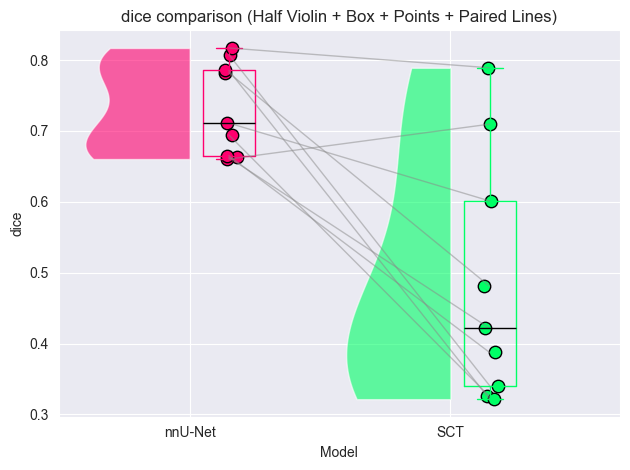

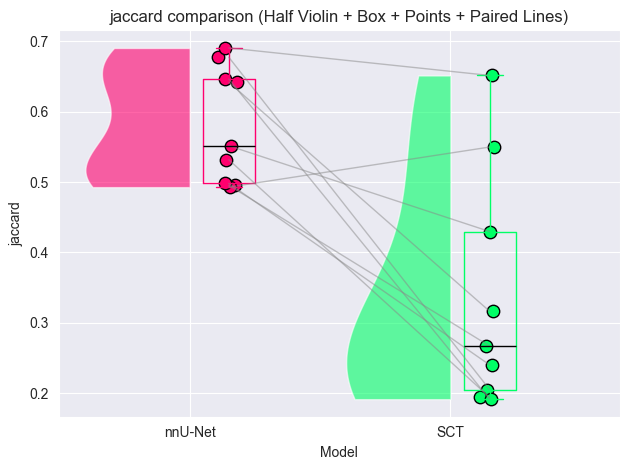

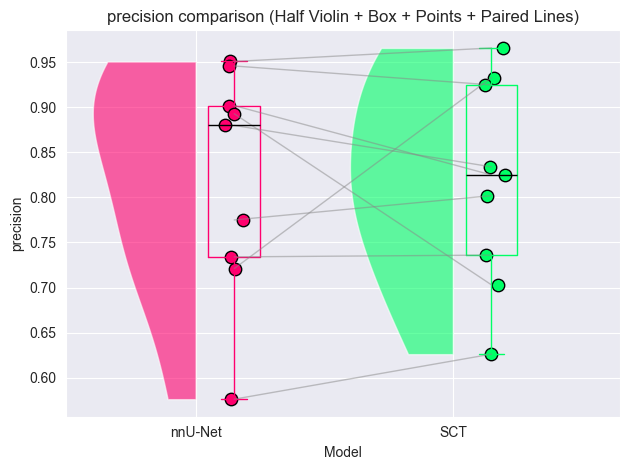

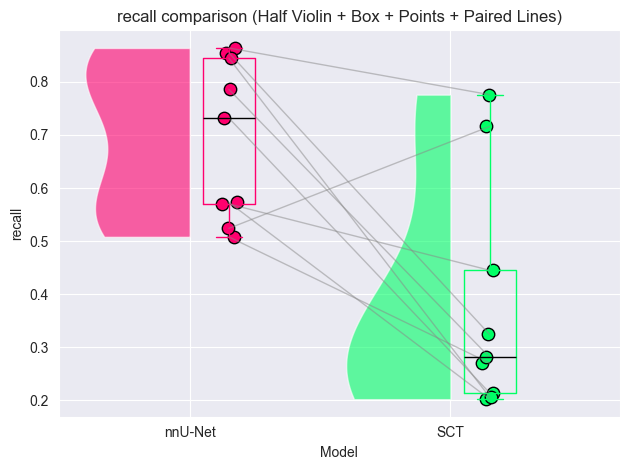

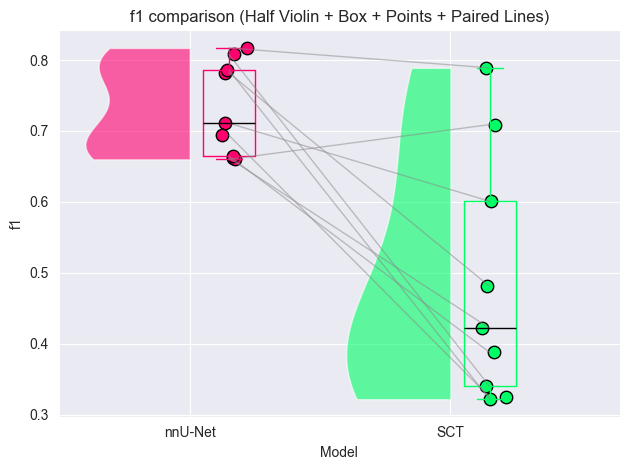

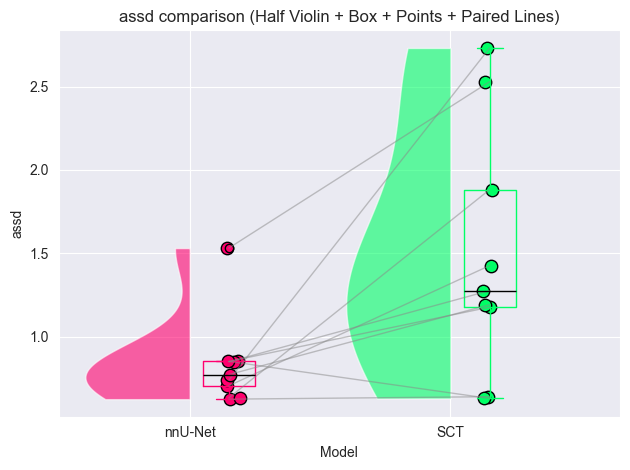

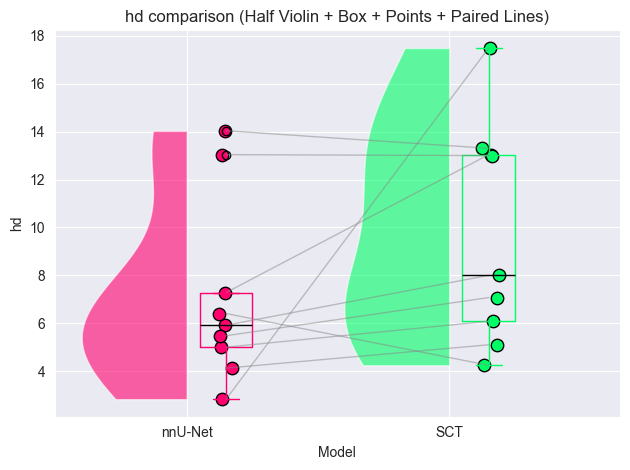

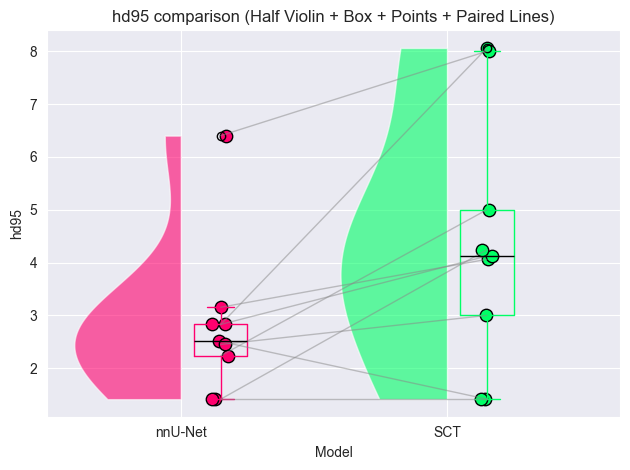

In [24]:
metrics = ["dice", "jaccard", "precision", "recall", "f1", "assd", "hd", "hd95"]
models = list(df["model"].unique())

# Define hex colors for each model
colors = {
    "nnU-Net": "#FF006E",
    "SCT": "#00FF66",
    # add more if needed
}

if "nnU-Net" in models and "SCT" in models:
    models = ["nnU-Net", "SCT"]

pos_dict = {model: i for i, model in enumerate(models)}

def half_violin(ax, data, pos, side="left", width=0.4, color=None, alpha=0.6):
    data = np.array(data)
    data = data[~np.isnan(data)]
    if len(data) < 2:
        return None
    kde = gaussian_kde(data)
    y = np.linspace(min(data), max(data), 200)
    v = kde(y)
    v = v / v.max() * width

    if side == "left":
        poly = ax.fill_betweenx(
            y,
            pos,
            pos - v,
            facecolor=color,   # use model color
            alpha=alpha
        )
    else:
        poly = ax.fill_betweenx(
            y,
            pos,
            pos + v,
            facecolor=color,
            alpha=alpha
        )
    return poly

for metric in metrics:
    plt.figure()
    ax = plt.gca()

    for model, pos in pos_dict.items():
        data = df[df["model"] == model][metric]
        model_color = colors.get(model, "#333333")  # fallback if not defined

        # Half violin with model-specific color
        poly = half_violin(ax, data, pos=pos, side="left", color=model_color)
        if poly is not None:
            violin_color = model_color
        else:
            violin_color = model_color  # still use model color even if no poly

        # Boxplot using model color for lines
        plt.boxplot(
            data,
            positions=[pos + 0.15],
            widths=0.2,
            vert=True,
            patch_artist=False,
            boxprops=dict(color=model_color),
            medianprops=dict(color="black"),
            whiskerprops=dict(color=model_color),
            capprops=dict(color=model_color),
        )

        # Jittered points with same model color
        jitter = np.random.normal(0, 0.02, size=len(data))
        x_vals = np.full(len(data), pos + 0.15) + jitter

        plt.scatter(
            x_vals,
            data,
            s=80,
            marker="o",
            color=violin_color,
            edgecolors="black"
        )

    # Paired lines between models (keep neutral or tweak if you want)
    for fname in df["file_name"].unique():
        sub = df[df["file_name"] == fname]
        if len(sub["model"].unique()) == len(models):
            x = [pos_dict[m] + 0.15 for m in models]
            y = [sub[sub["model"] == m][metric].values[0] for m in models]
            plt.plot(x, y, alpha=0.5, linewidth=1, color="#888888")

    plt.xticks(range(len(models)), models)
    plt.title(f"{metric} comparison (Half Violin + Box + Points + Paired Lines)")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.tight_layout()
    plt.savefig(f"{metric} figure.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

In [10]:
# print the best and worst case for both conditions
# get best and worst for nnunet
for model in models:
    sub_df = df[df["model"] == model]
    best_row = sub_df.loc[sub_df["dice"].idxmax()]
    worst_row = sub_df.loc[sub_df["dice"].idxmin()]
    print(f"Model: {model}")
    print(" Best case:")
    print(best_row)
    print(" Worst case:")
    print(worst_row)

Model: nnU-Net
 Best case:
file_name    SCIEMG_019.nii.gz
model                  nnU-Net
dice                  0.817025
jaccard               0.690653
precision                0.775
recall                   0.864
f1                       0.817
assd                  0.623982
hd                   13.038405
hd95                  1.414214
Name: 8, dtype: object
 Worst case:
file_name    SCIEMG_027.nii.gz
model                  nnU-Net
dice                    0.6603
jaccard               0.492872
precision                0.893
recall                   0.524
f1                        0.66
assd                   0.85089
hd                    6.403124
hd95                   2.50633
Name: 12, dtype: object
Model: SCT
 Best case:
file_name    SCIEMG_019.nii.gz
model                      SCT
dice                  0.789058
jaccard               0.651607
precision                0.802
recall                   0.776
f1                       0.789
assd                  0.638842
hd                    

Model: nnU-Net | Case: Best | File: SCIEMG_019.nii.gz


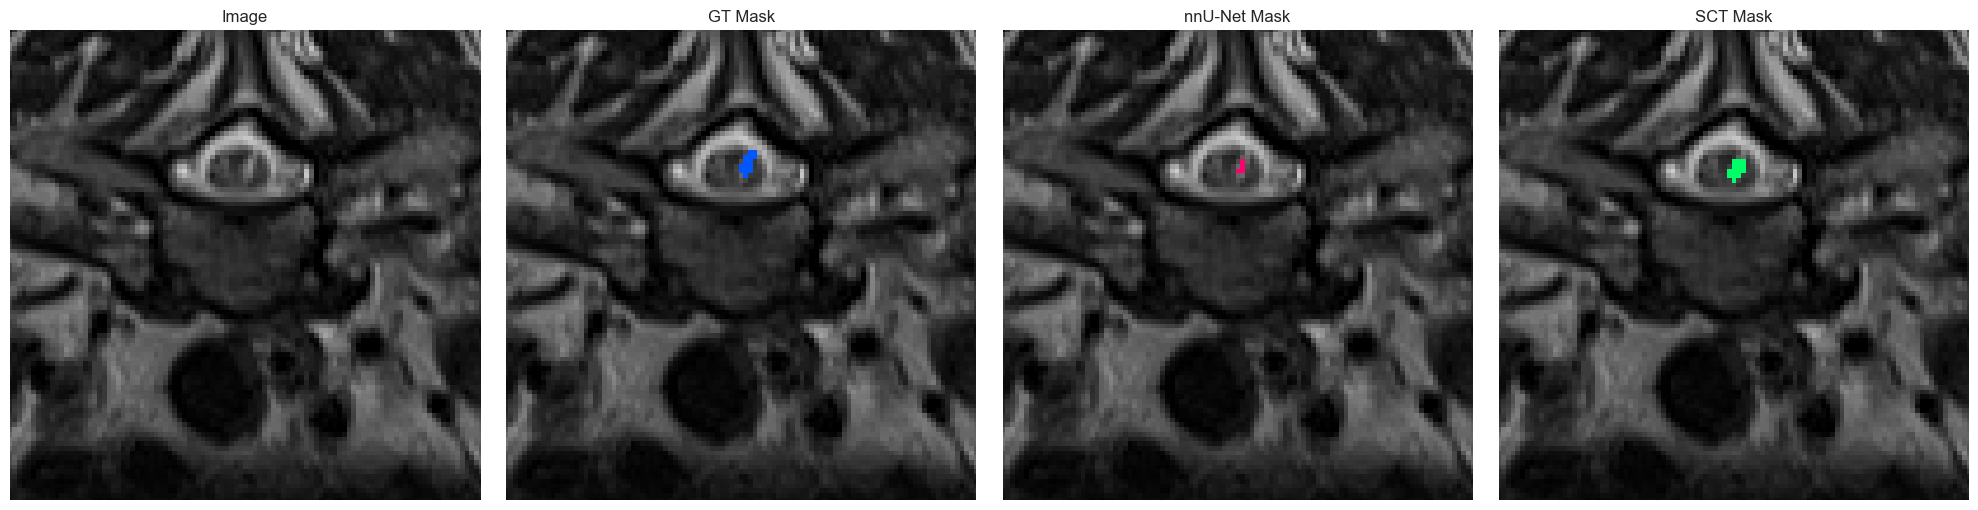

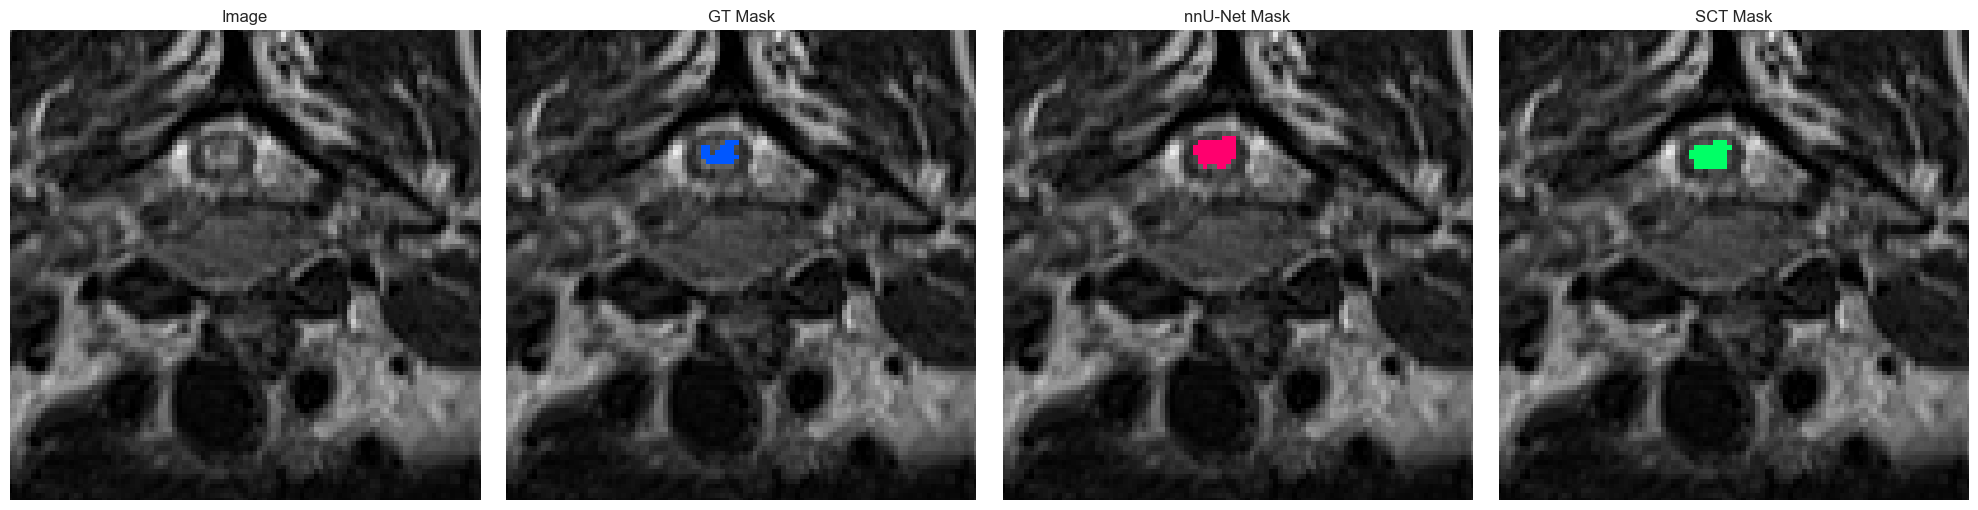

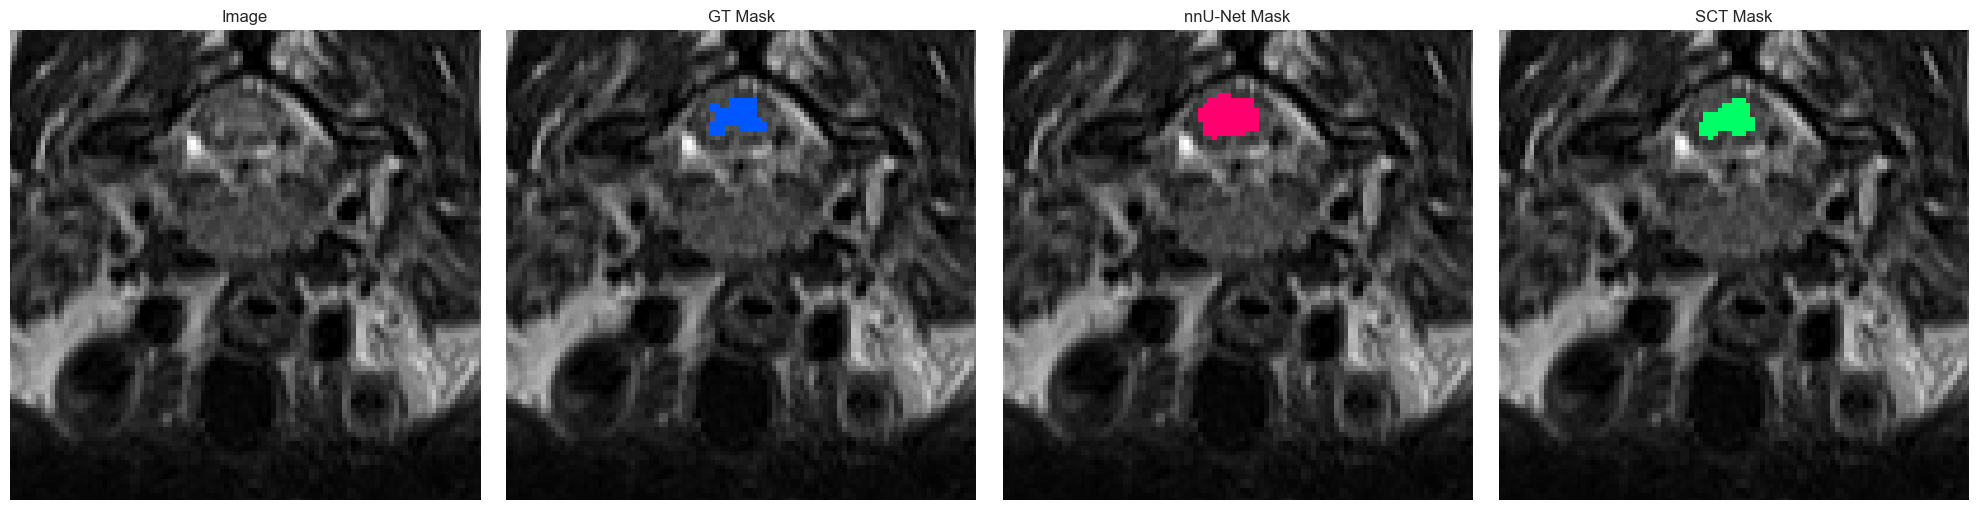

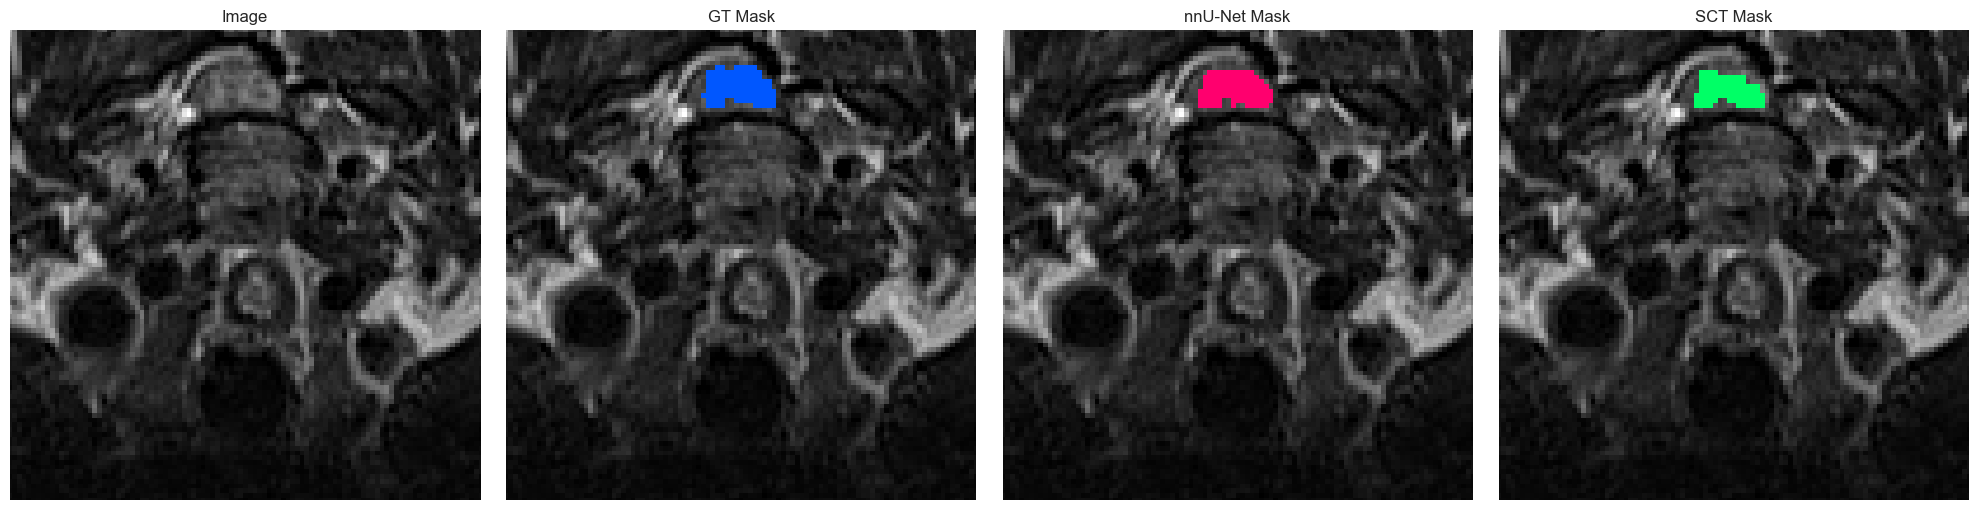

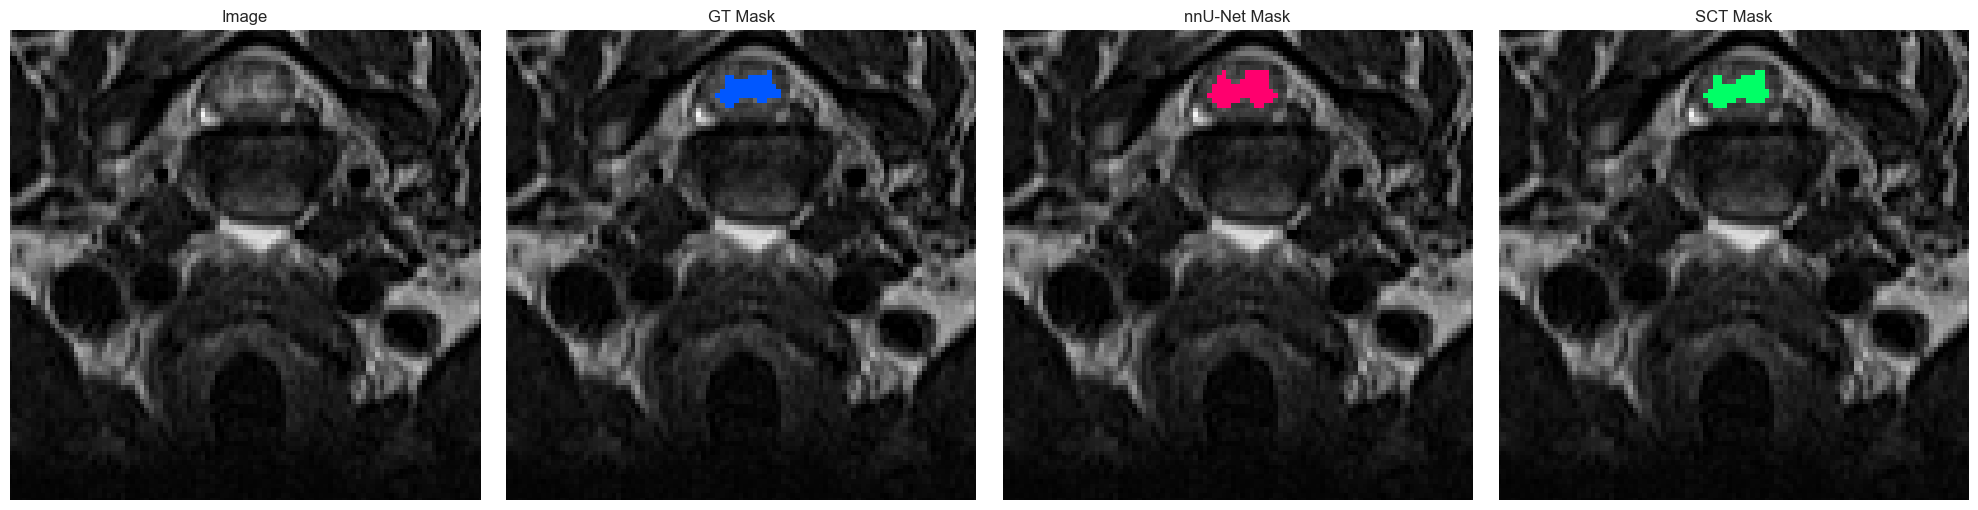

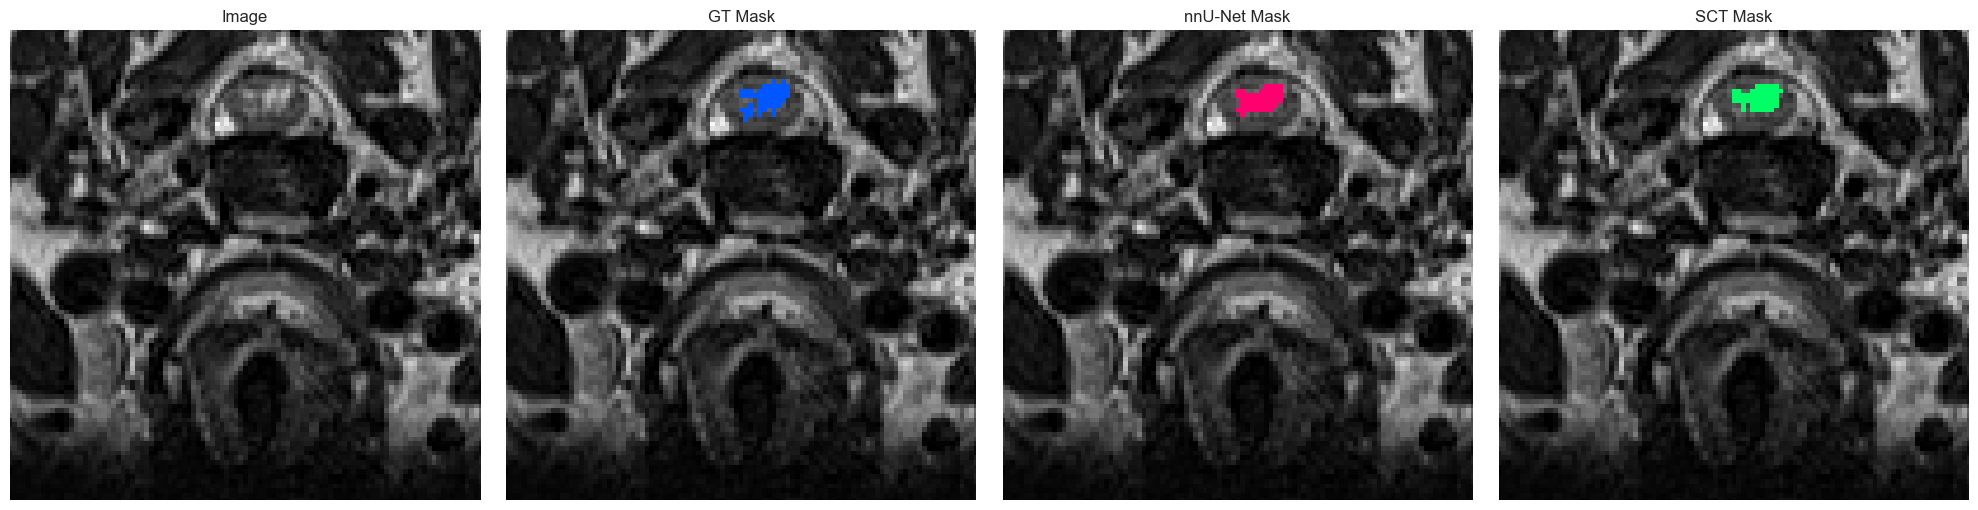

No mask found in slice 23


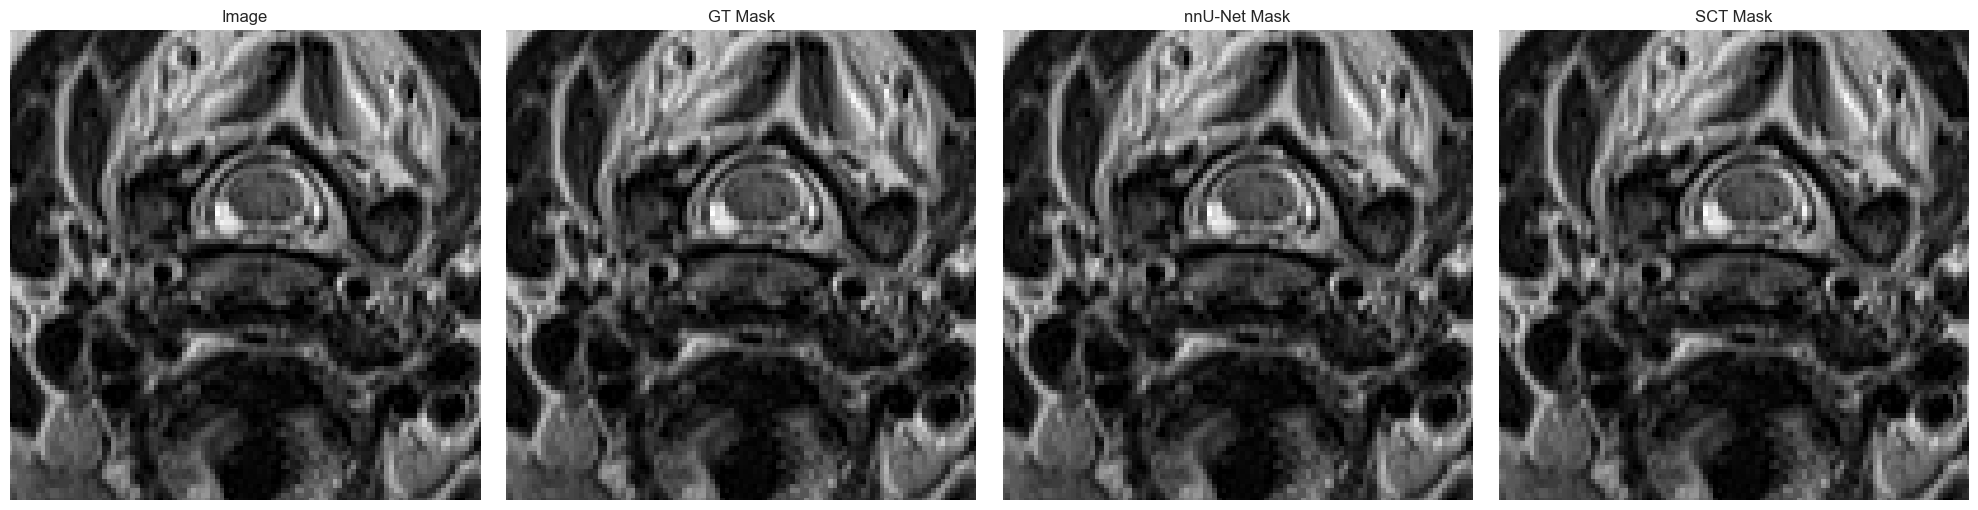

No mask found in slice 26


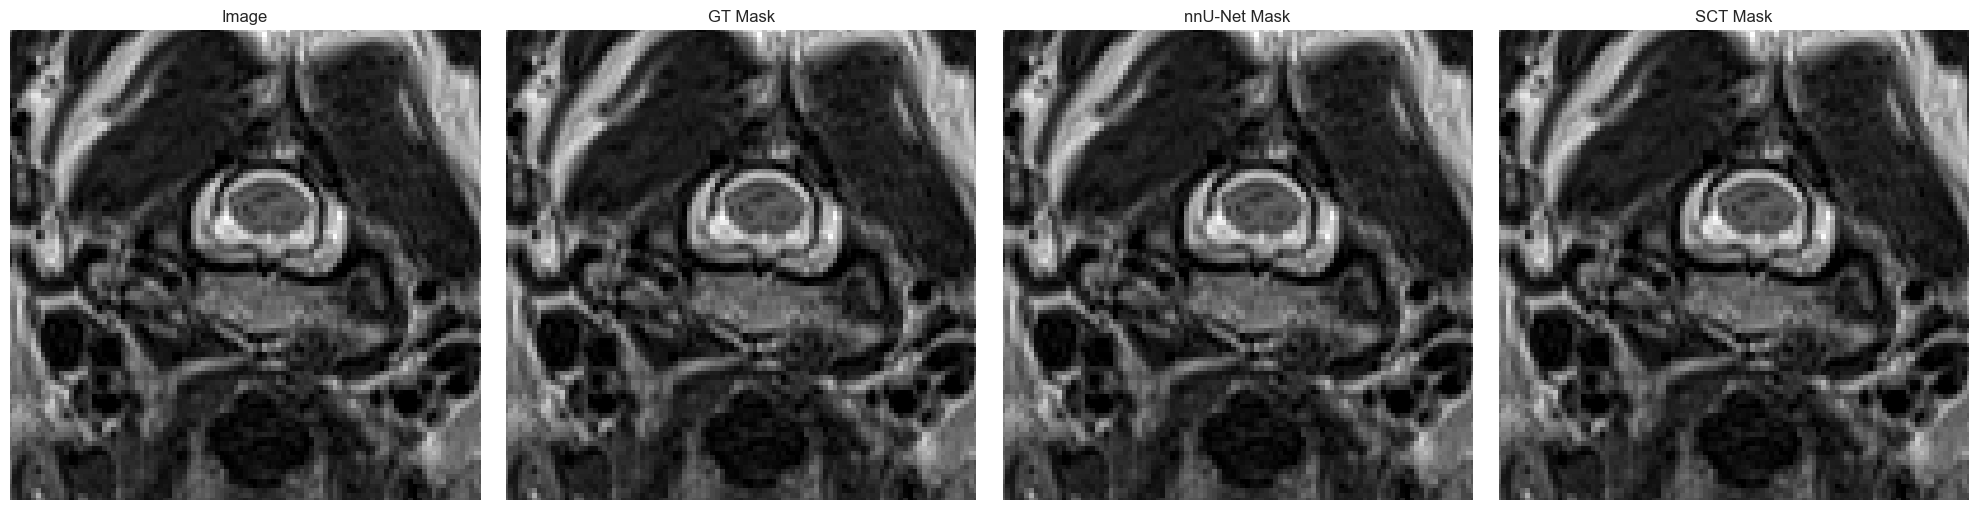

No mask found in slice 29


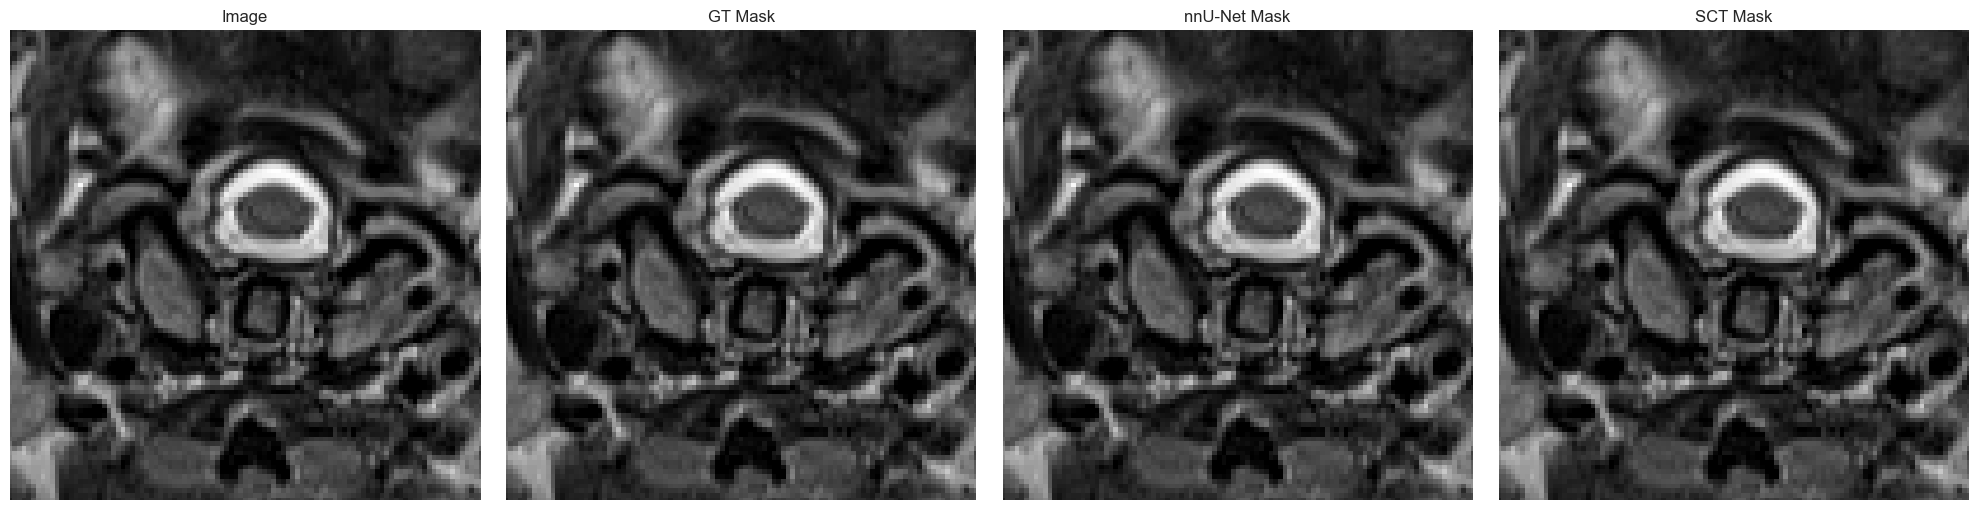

No mask found in slice 32


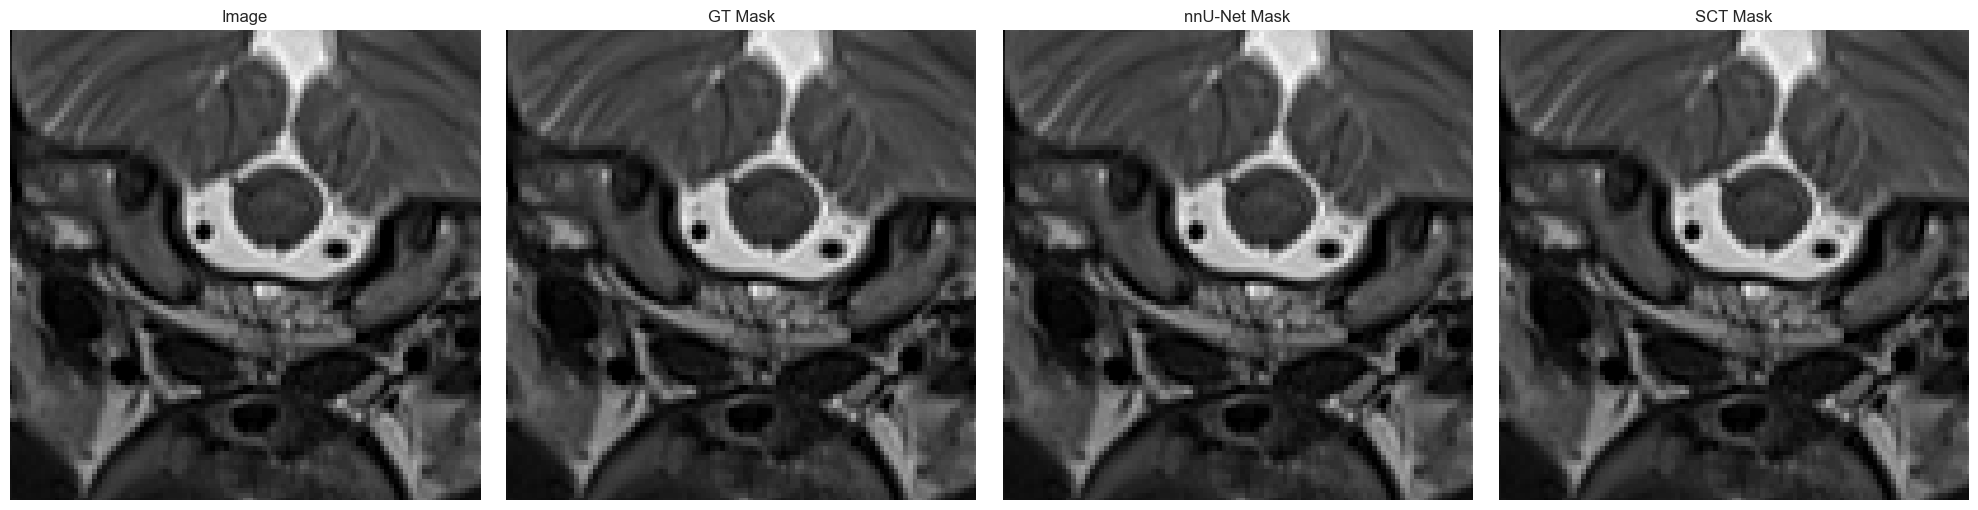

Model: nnU-Net | Case: Worst | File: SCIEMG_027.nii.gz


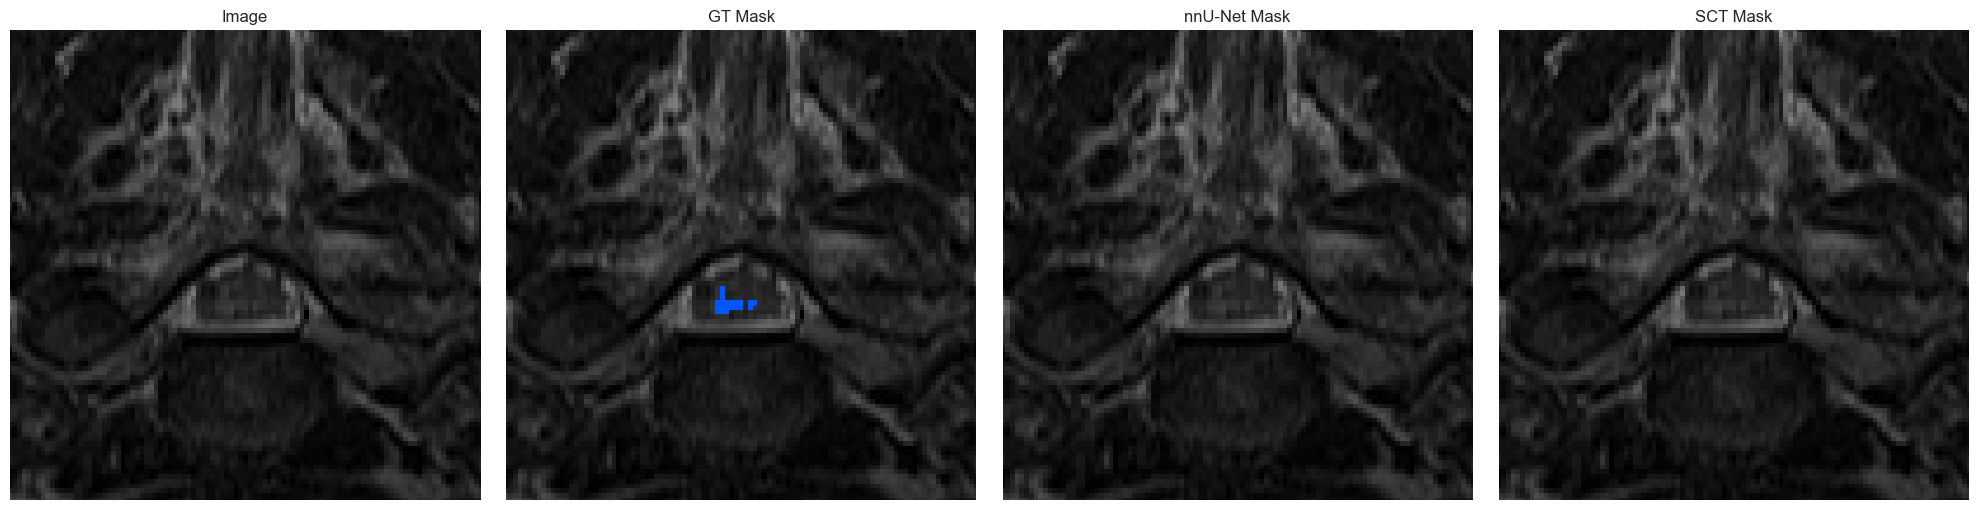

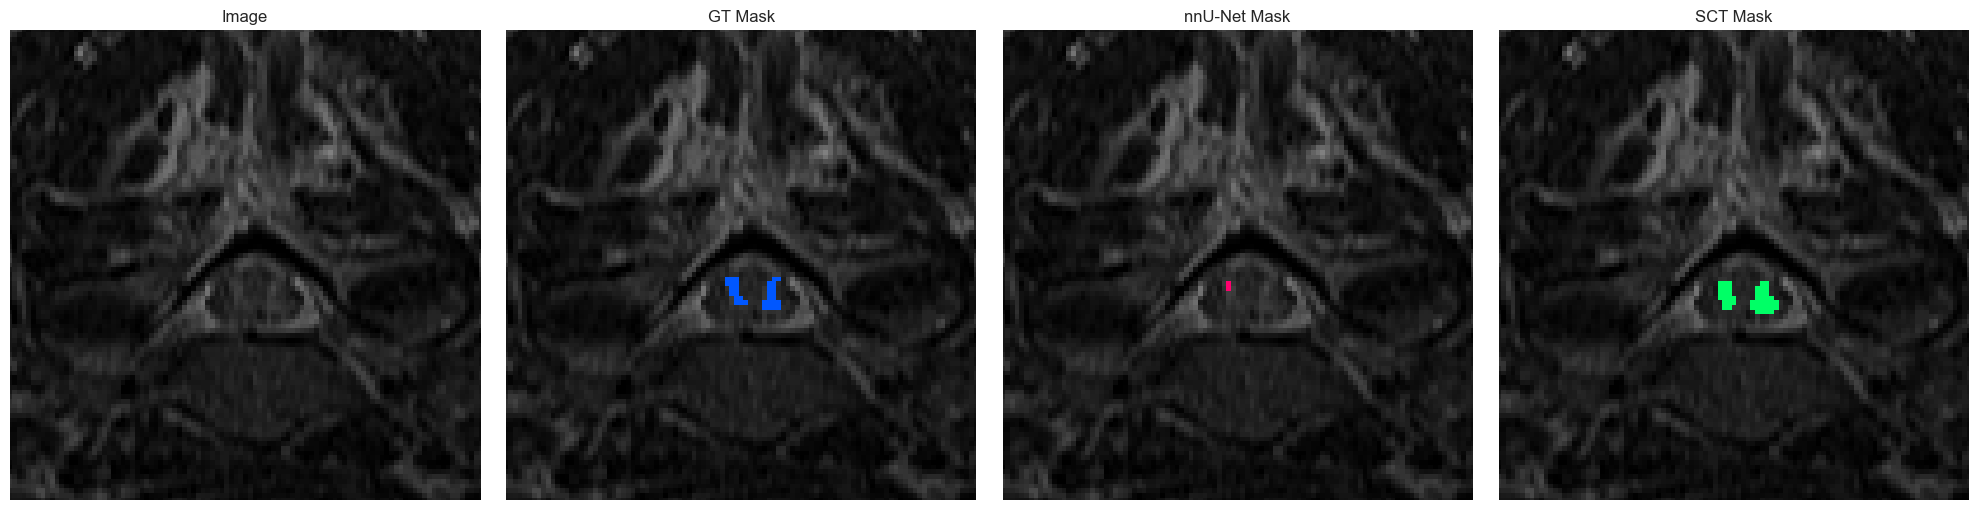

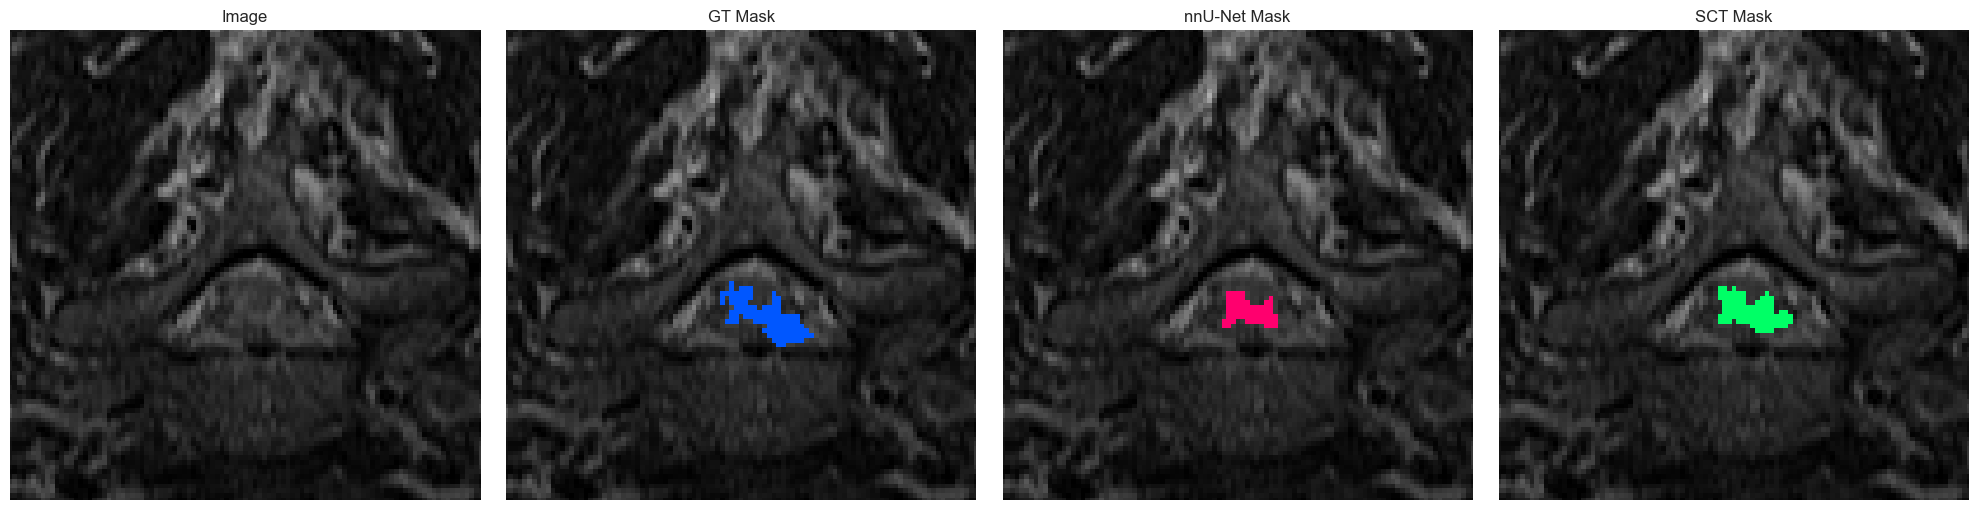

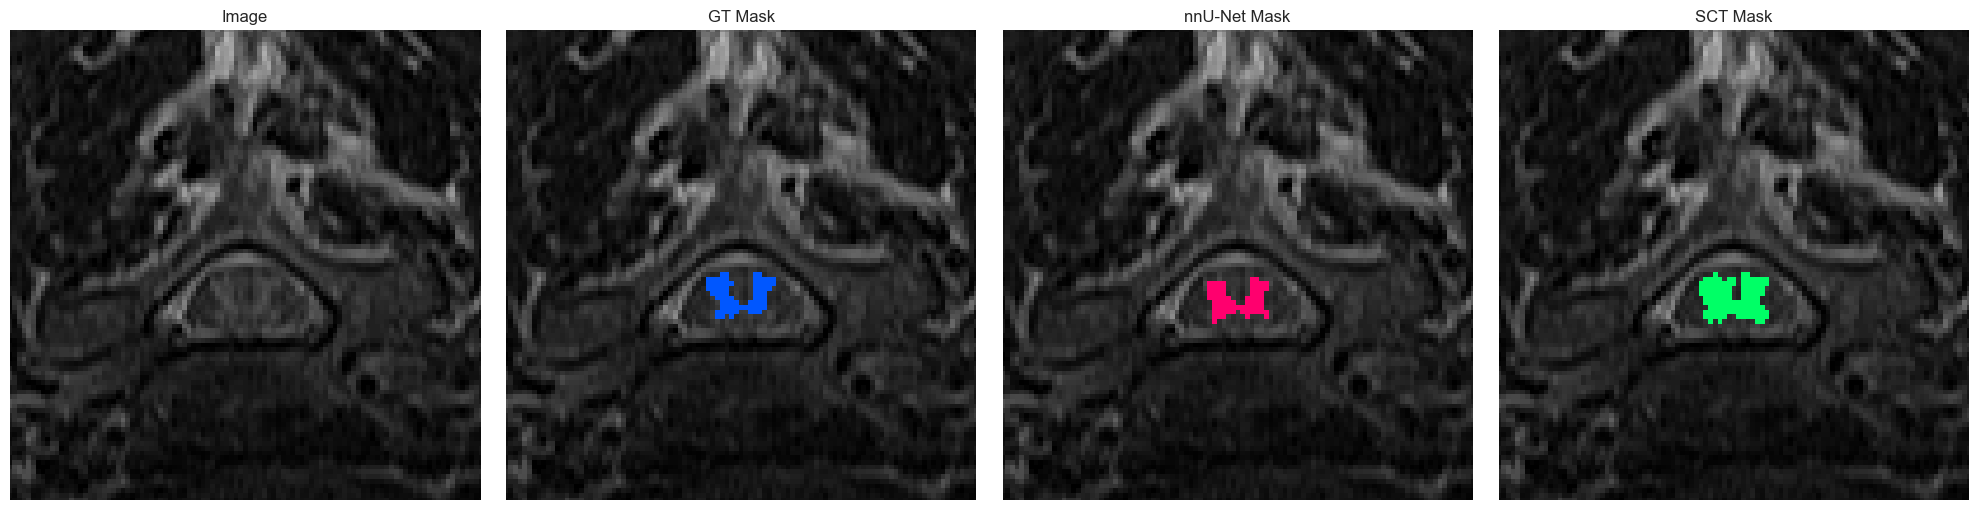

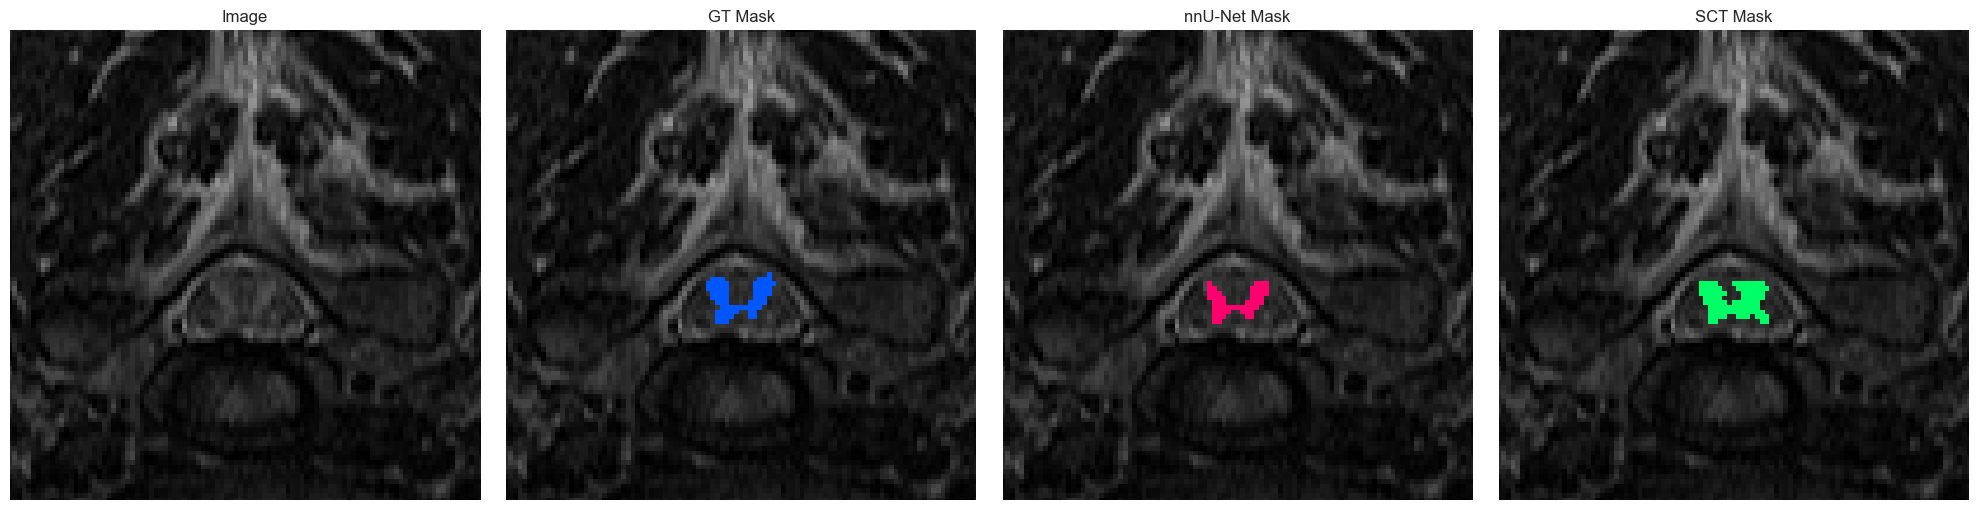

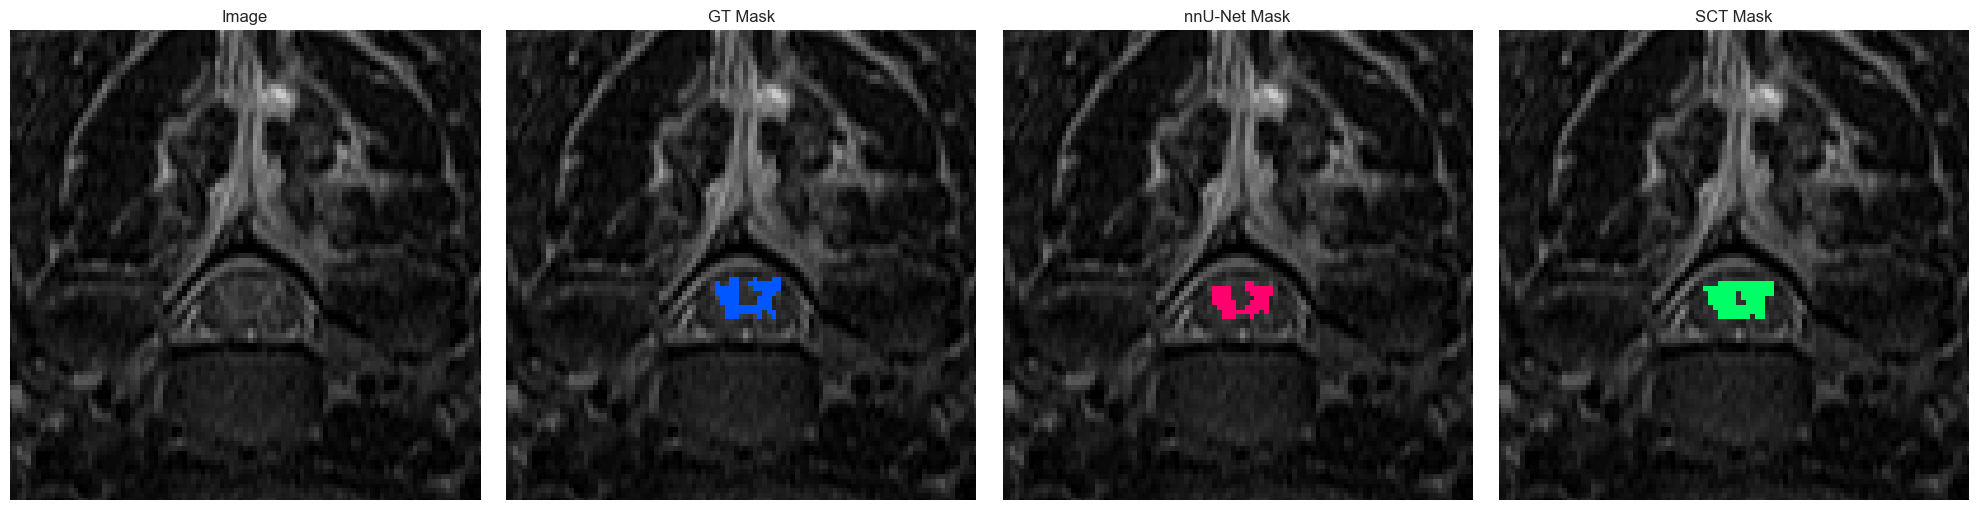

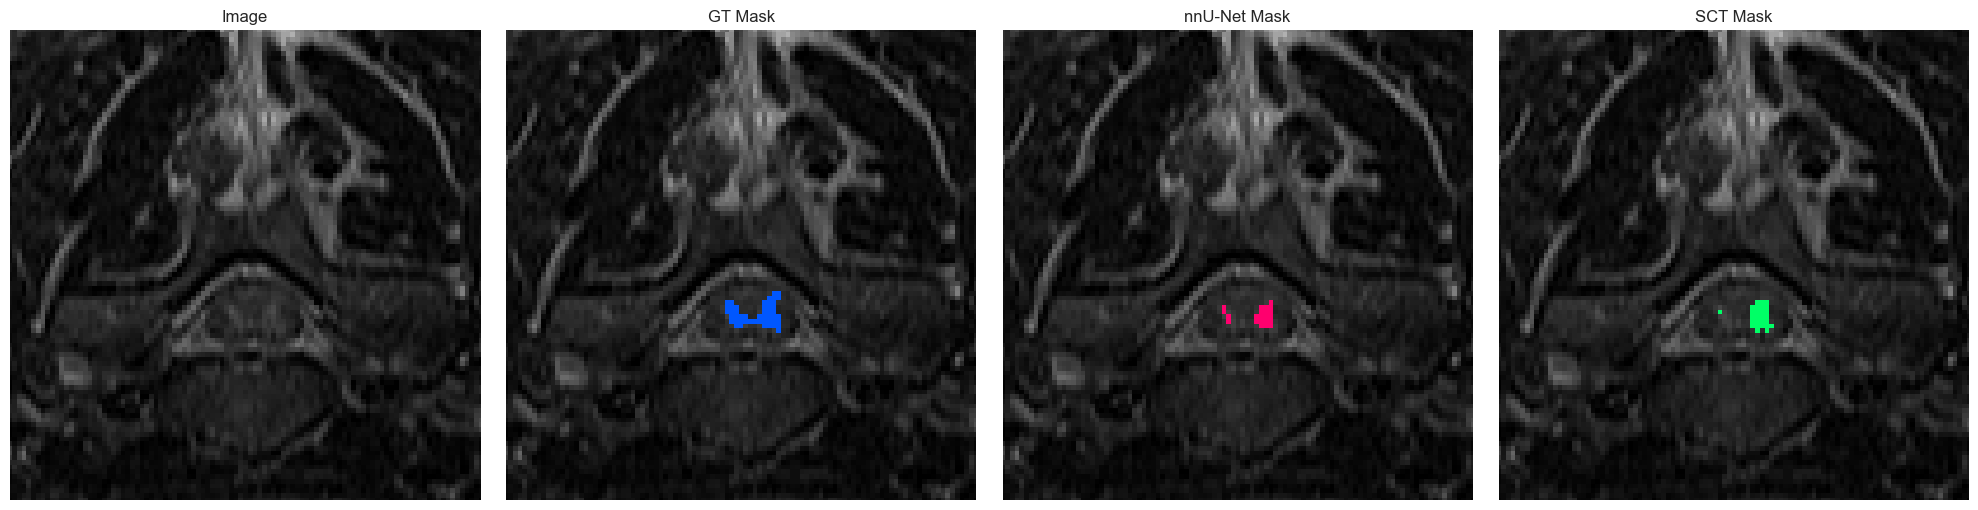

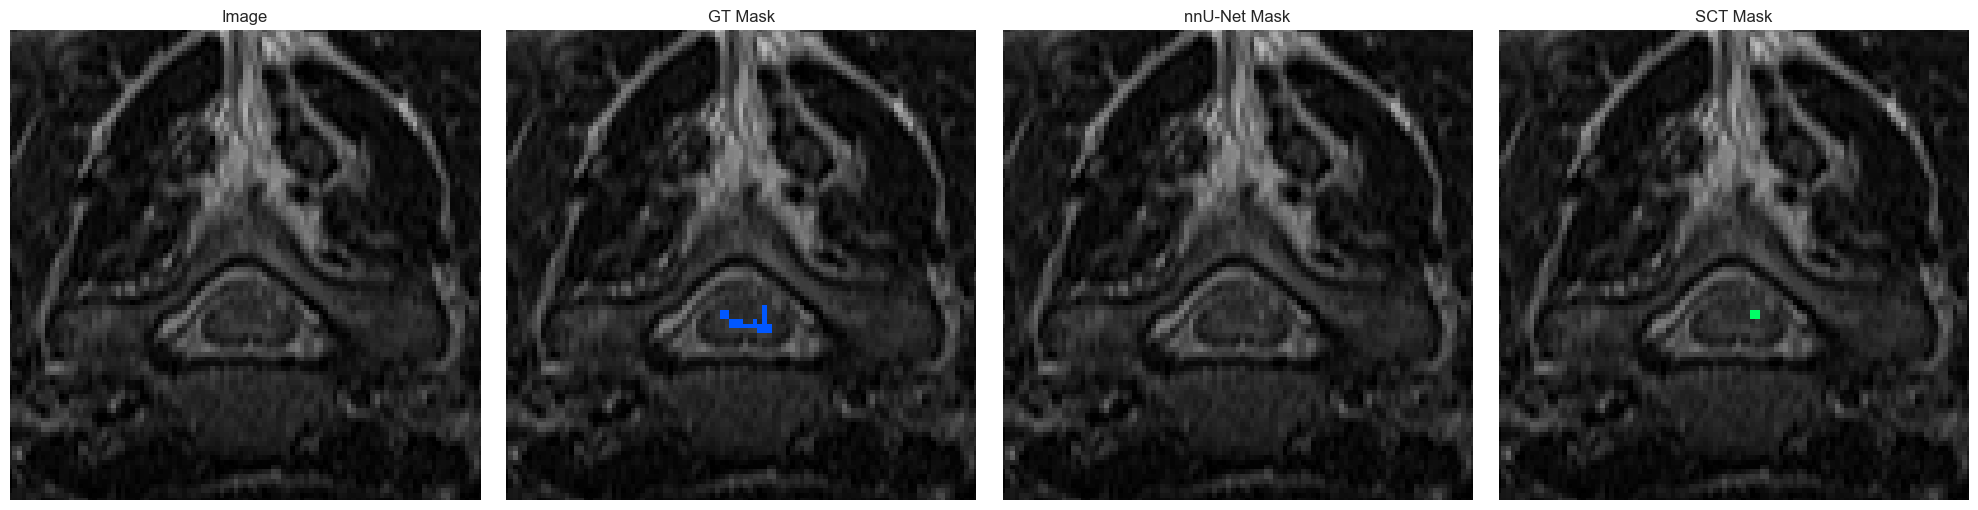

Model: SCT | Case: Best | File: SCIEMG_019.nii.gz


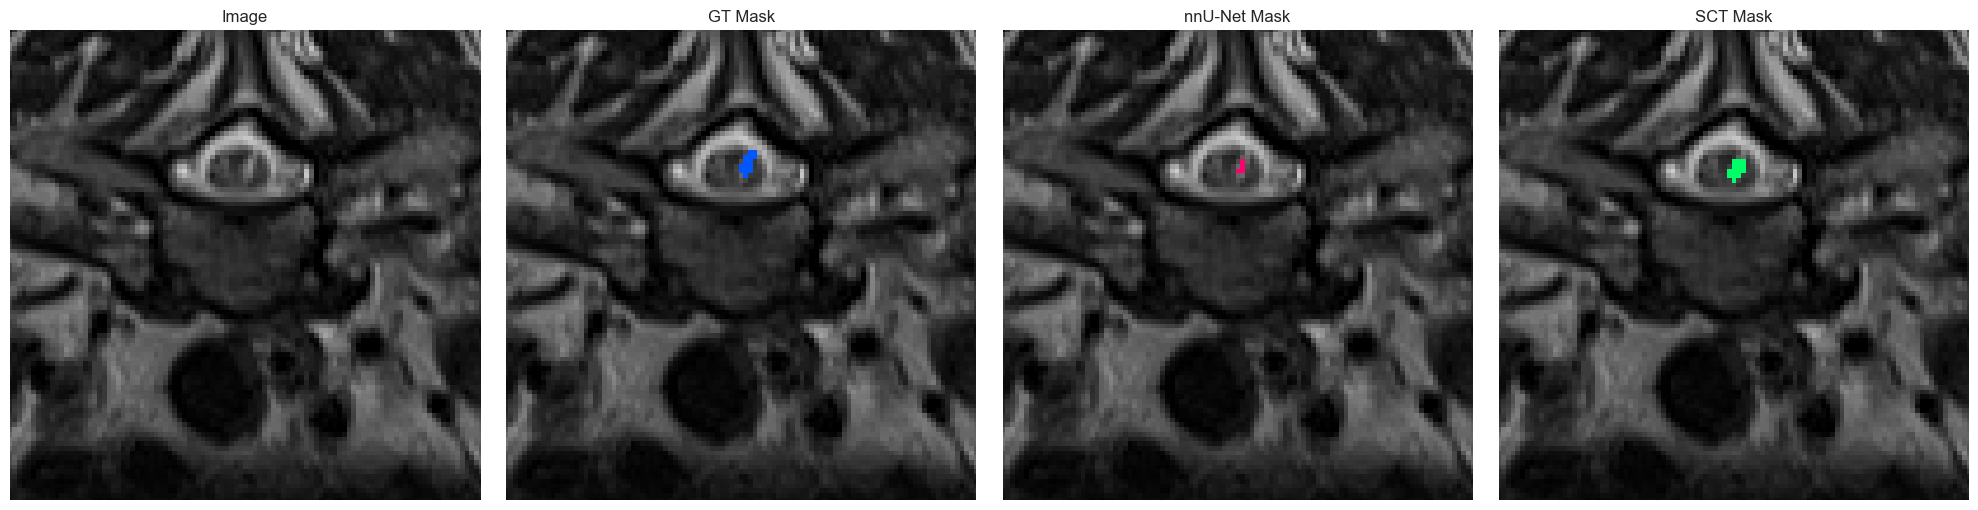

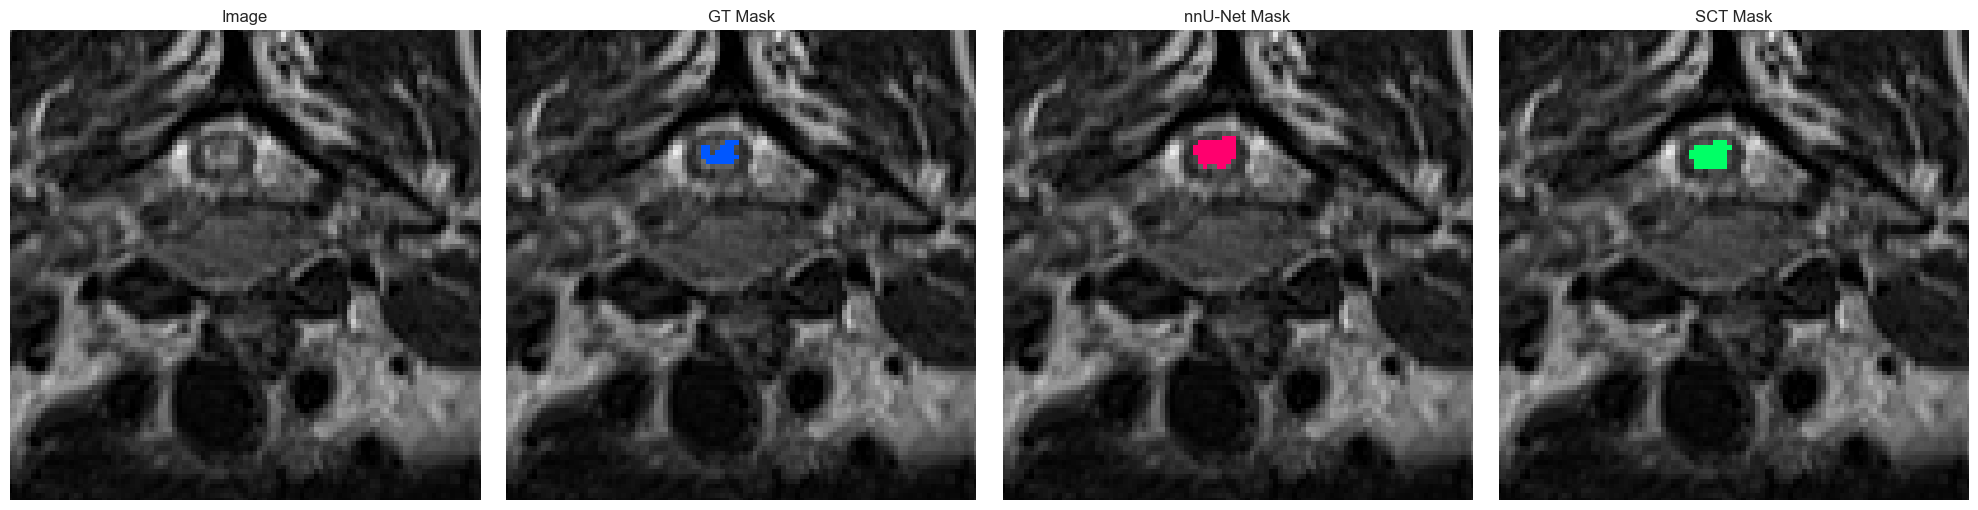

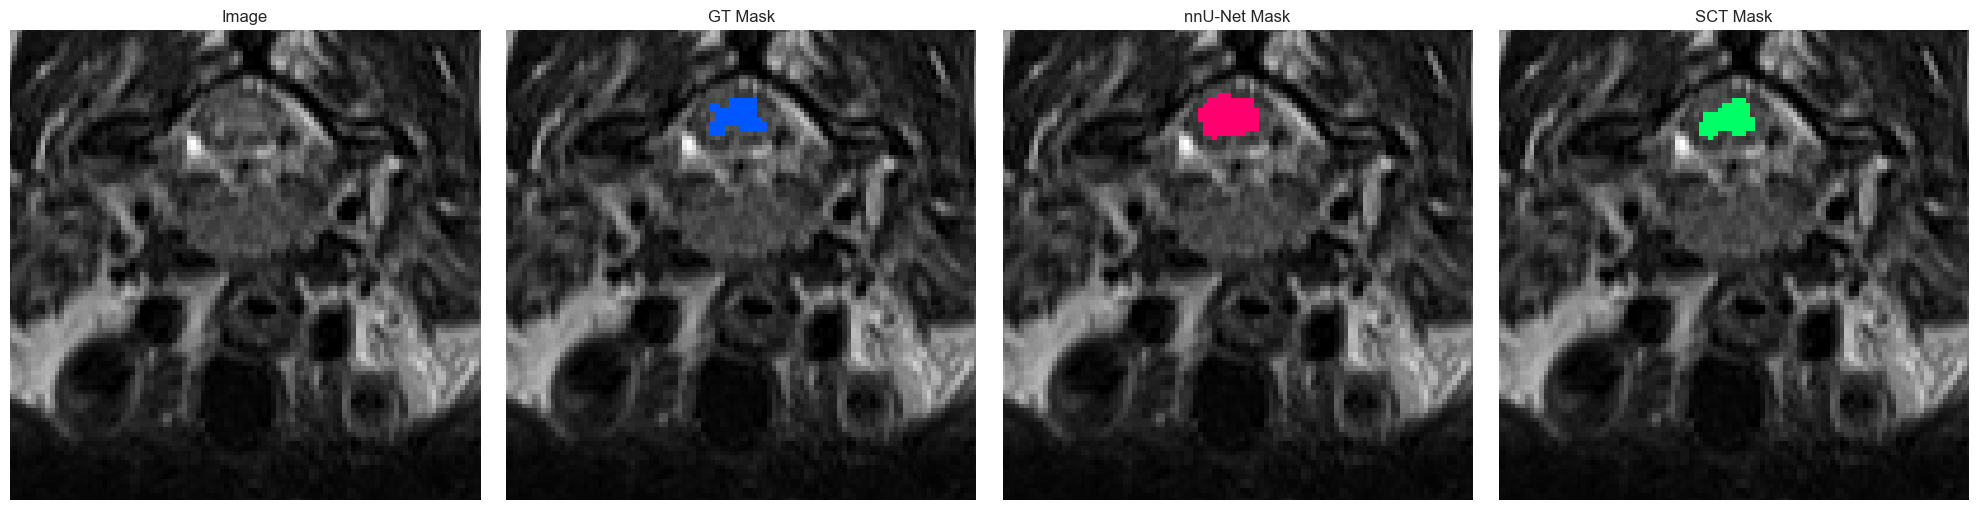

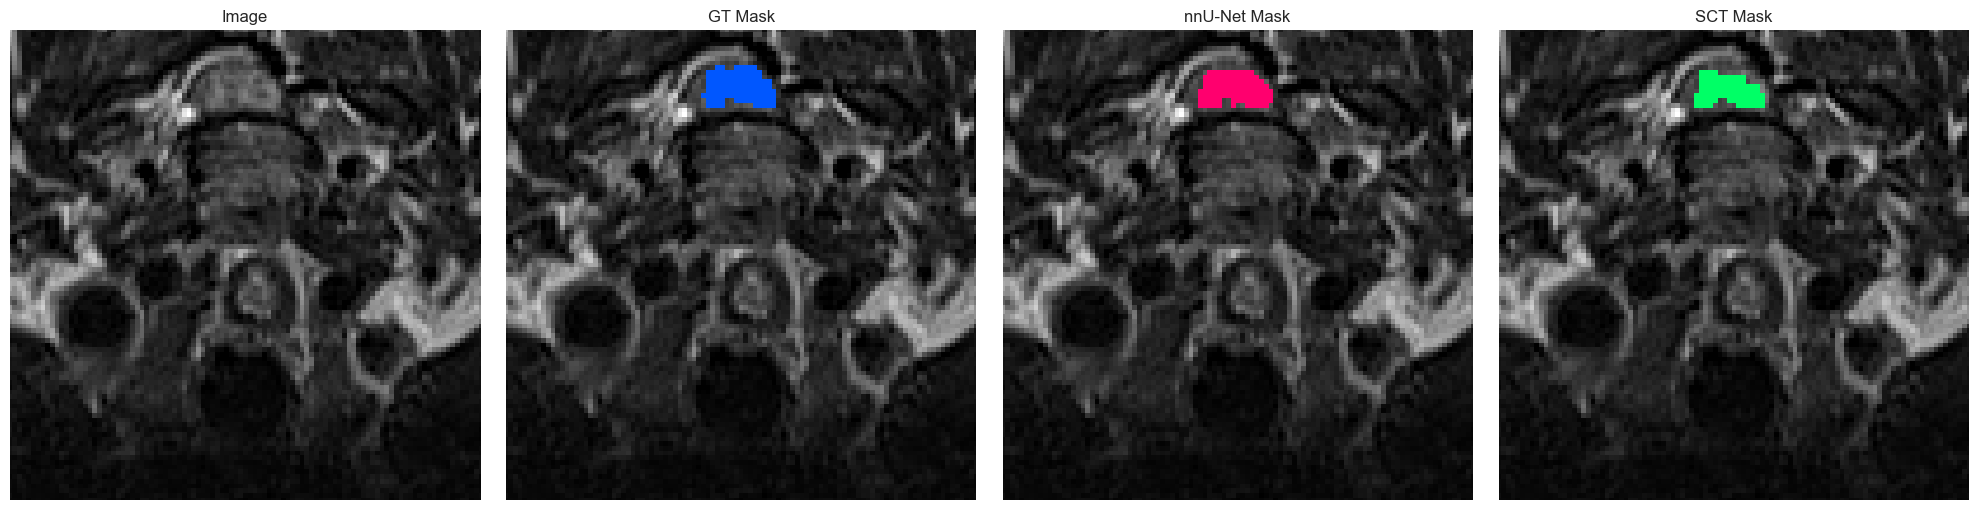

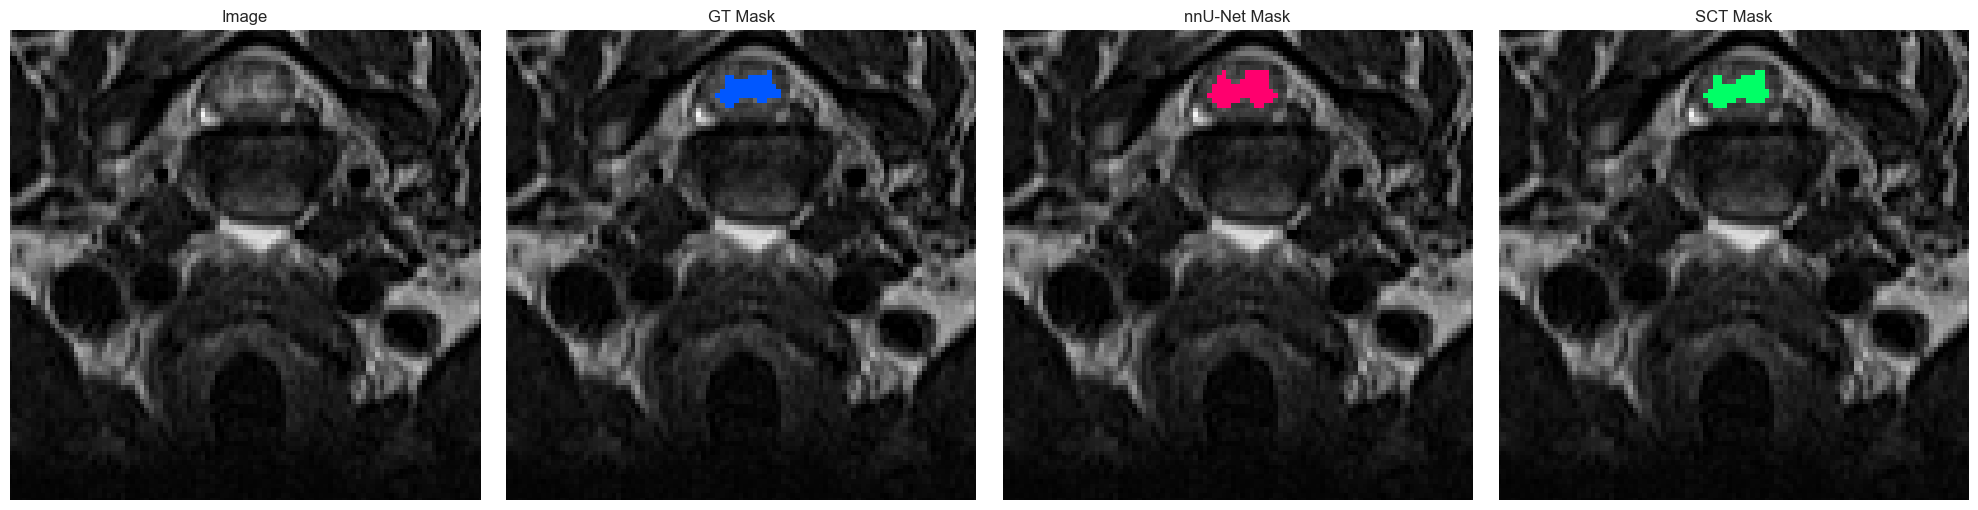

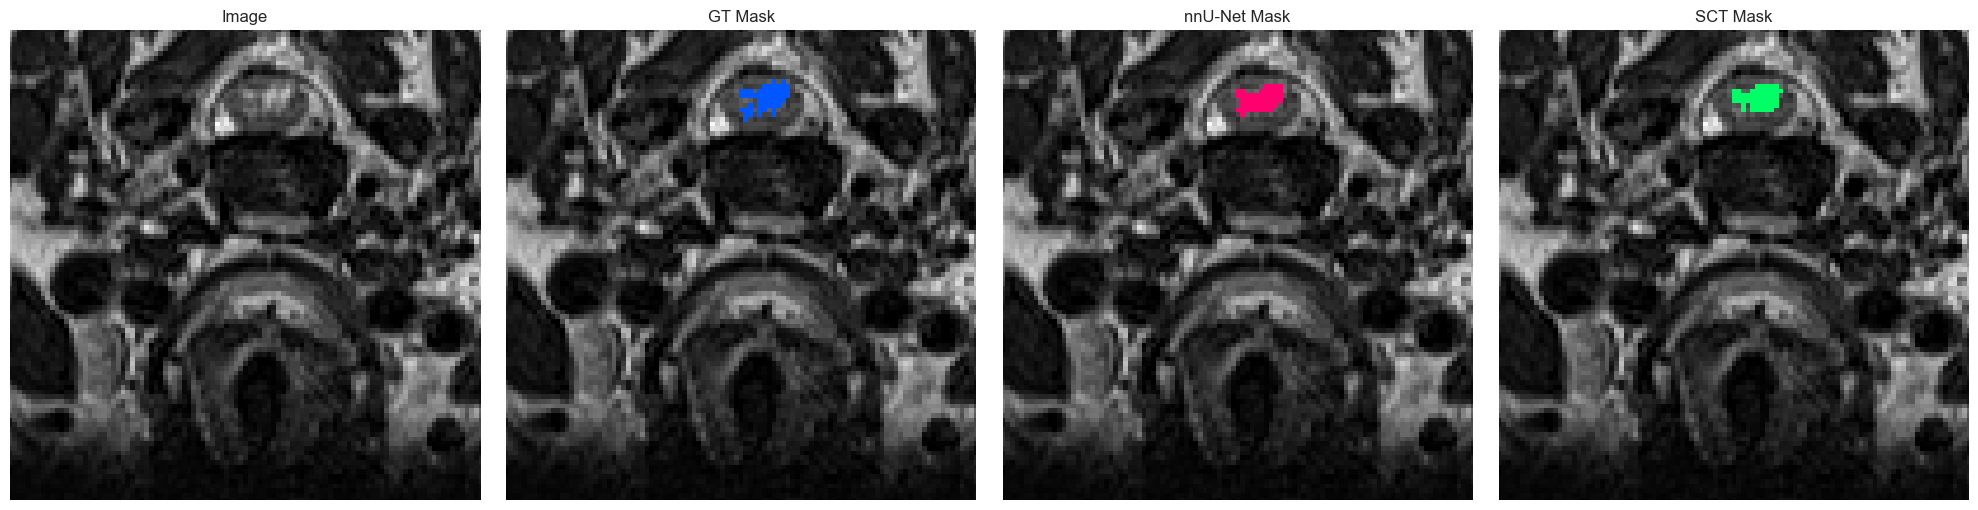

No mask found in slice 23


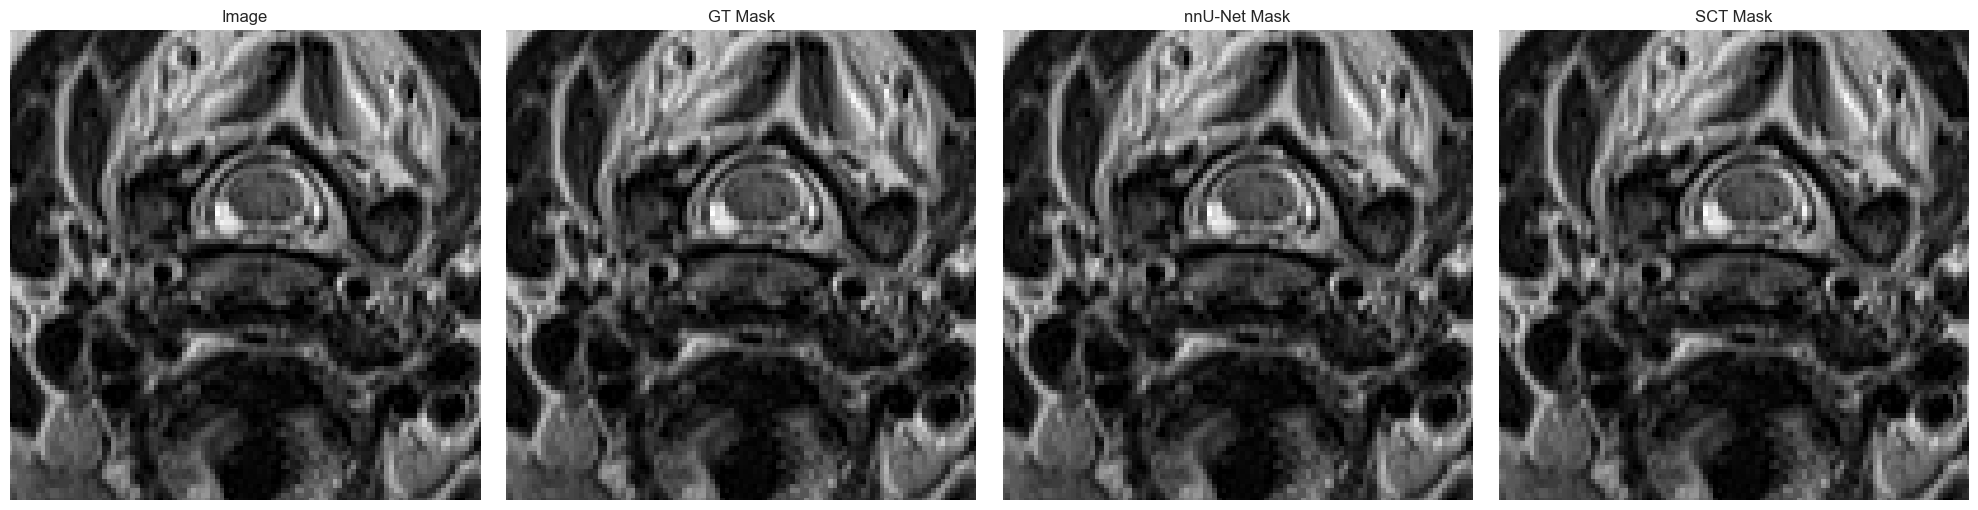

No mask found in slice 26


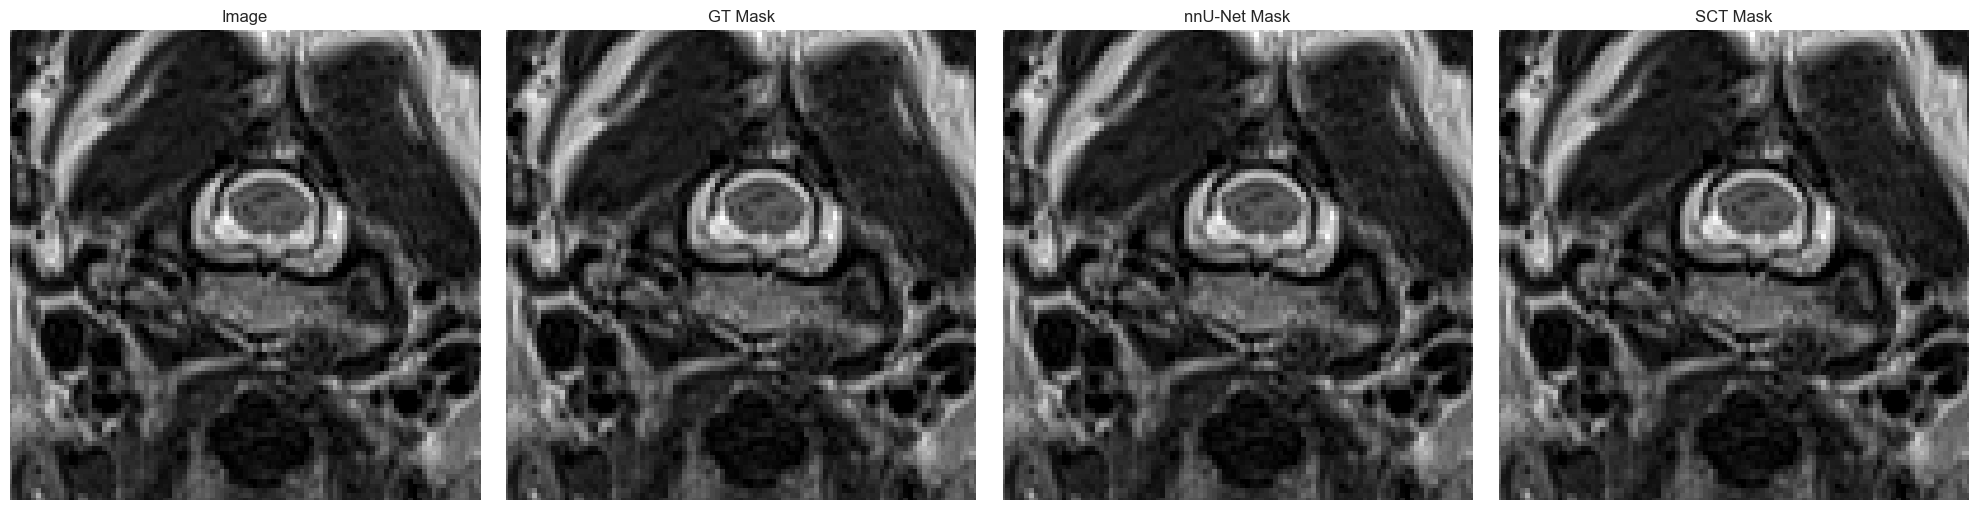

No mask found in slice 29


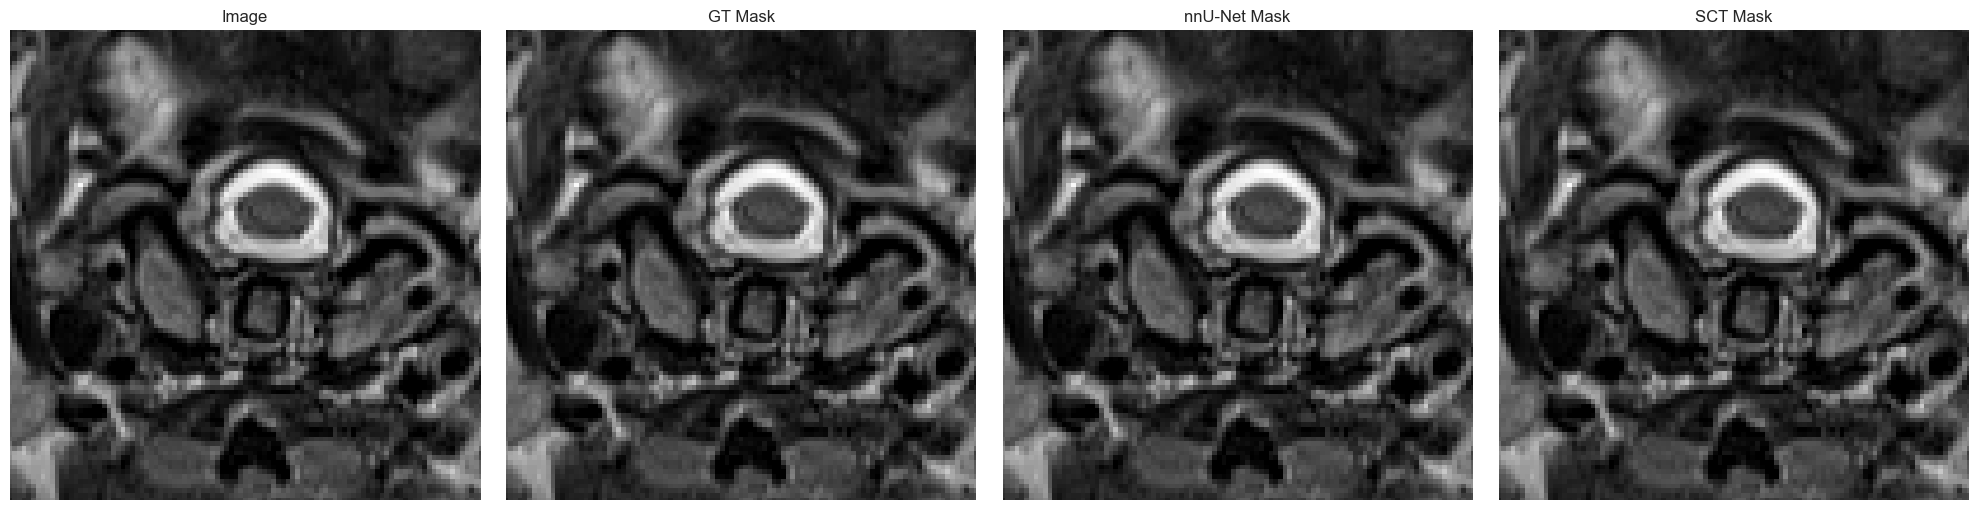

No mask found in slice 32


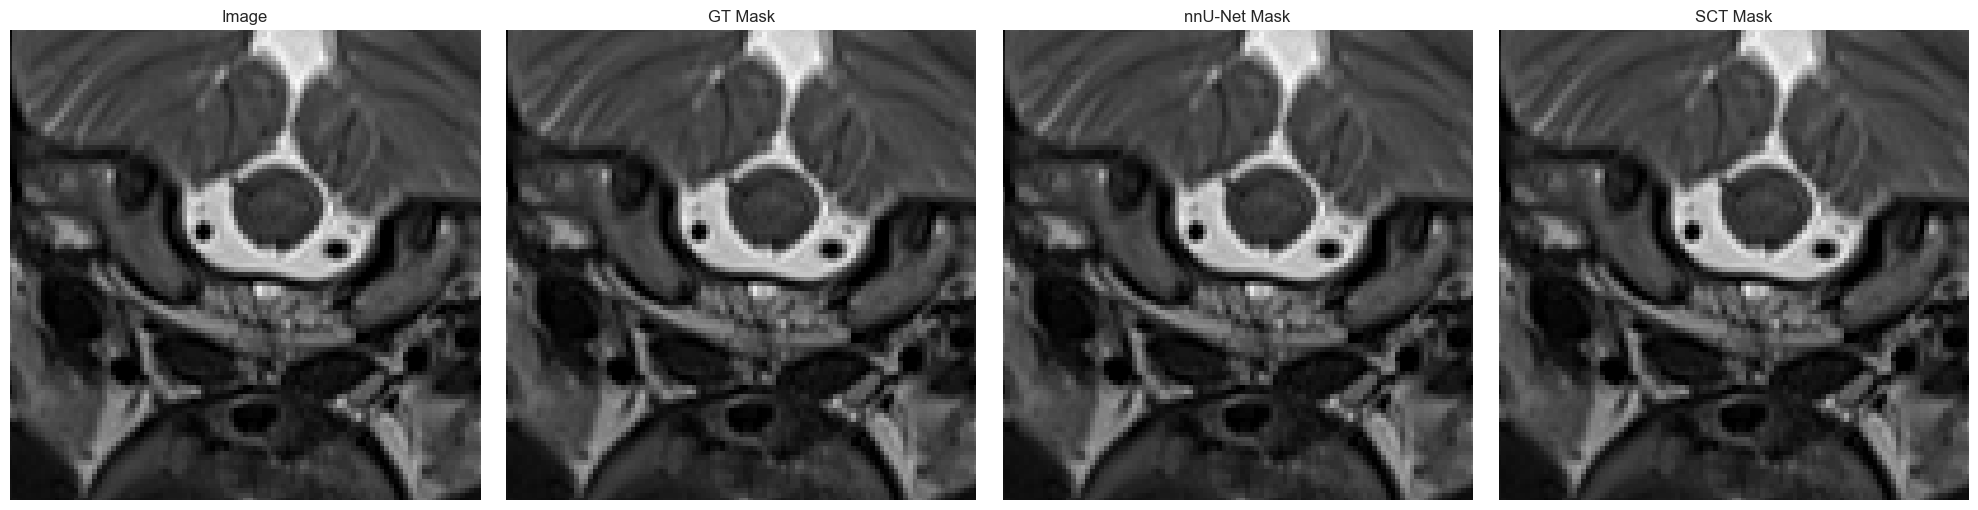

Model: SCT | Case: Worst | File: SCIEMG_031.nii.gz


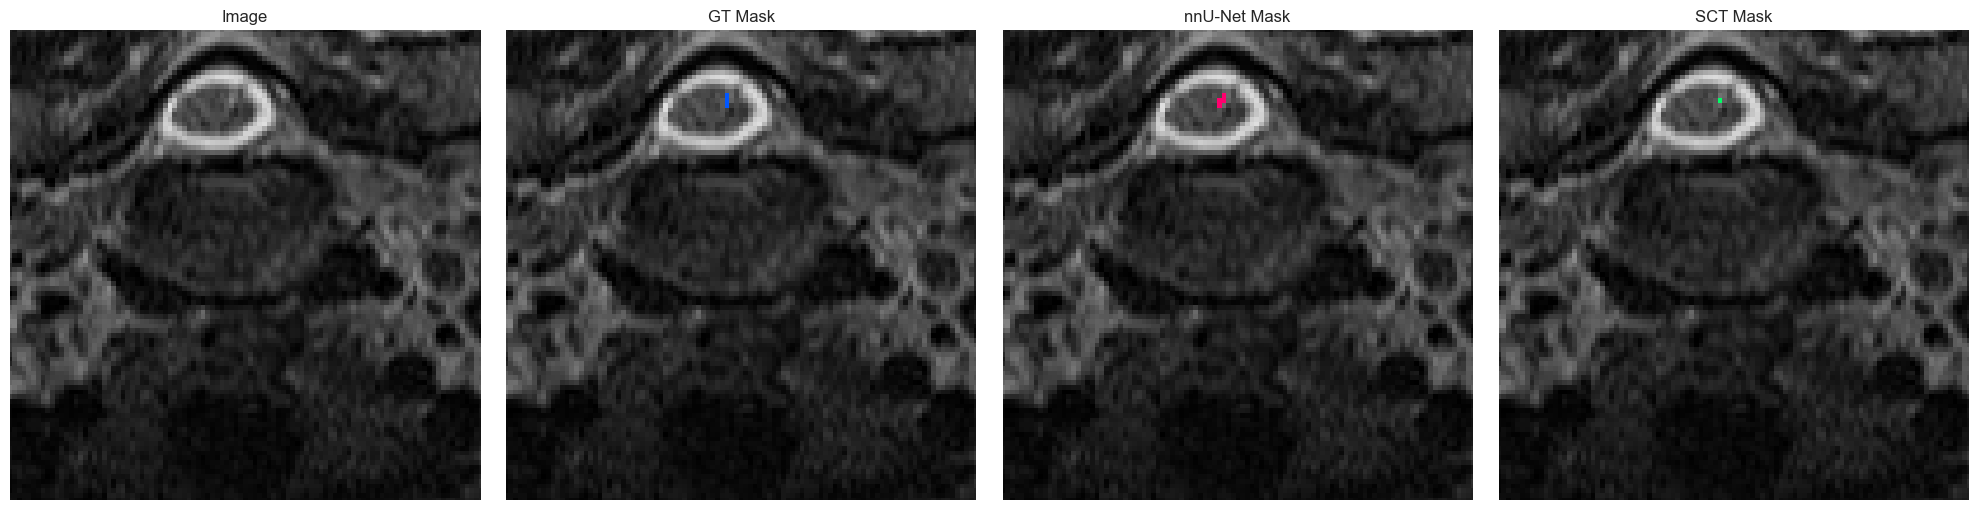

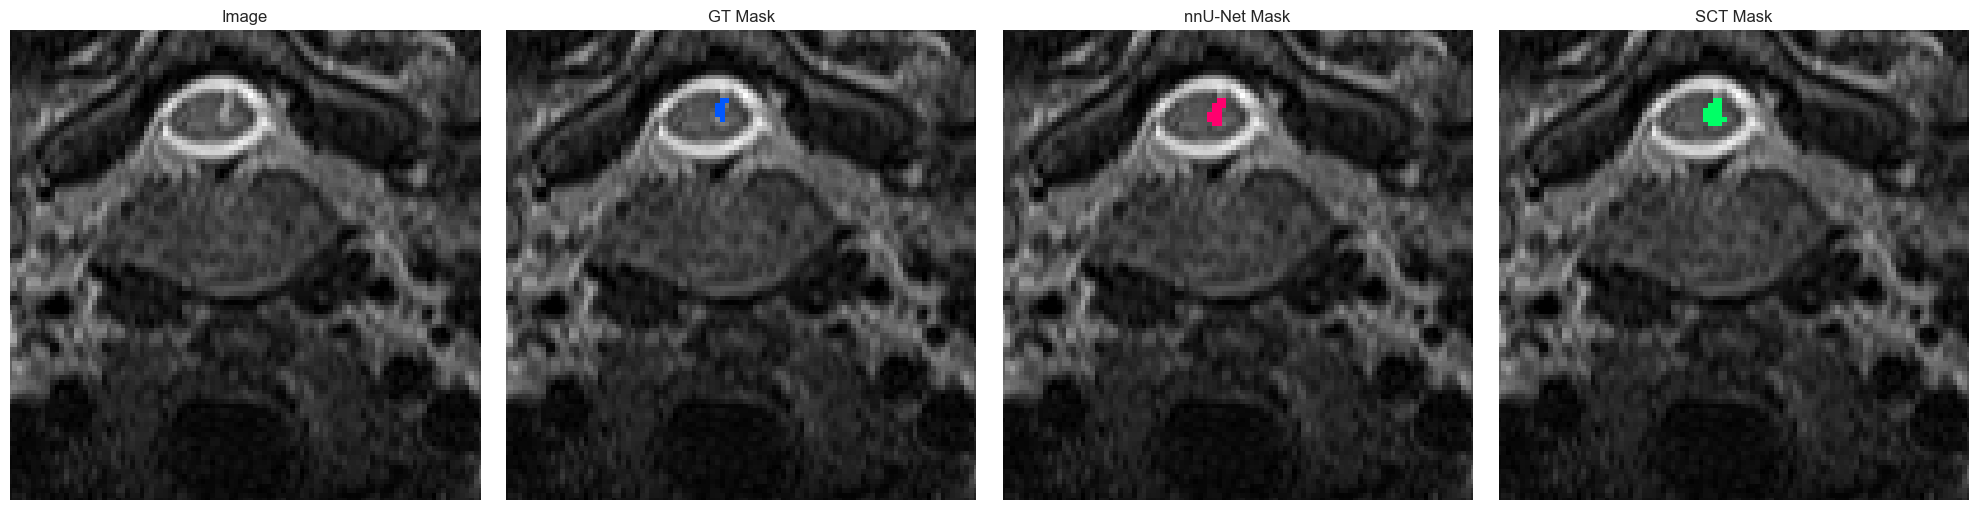

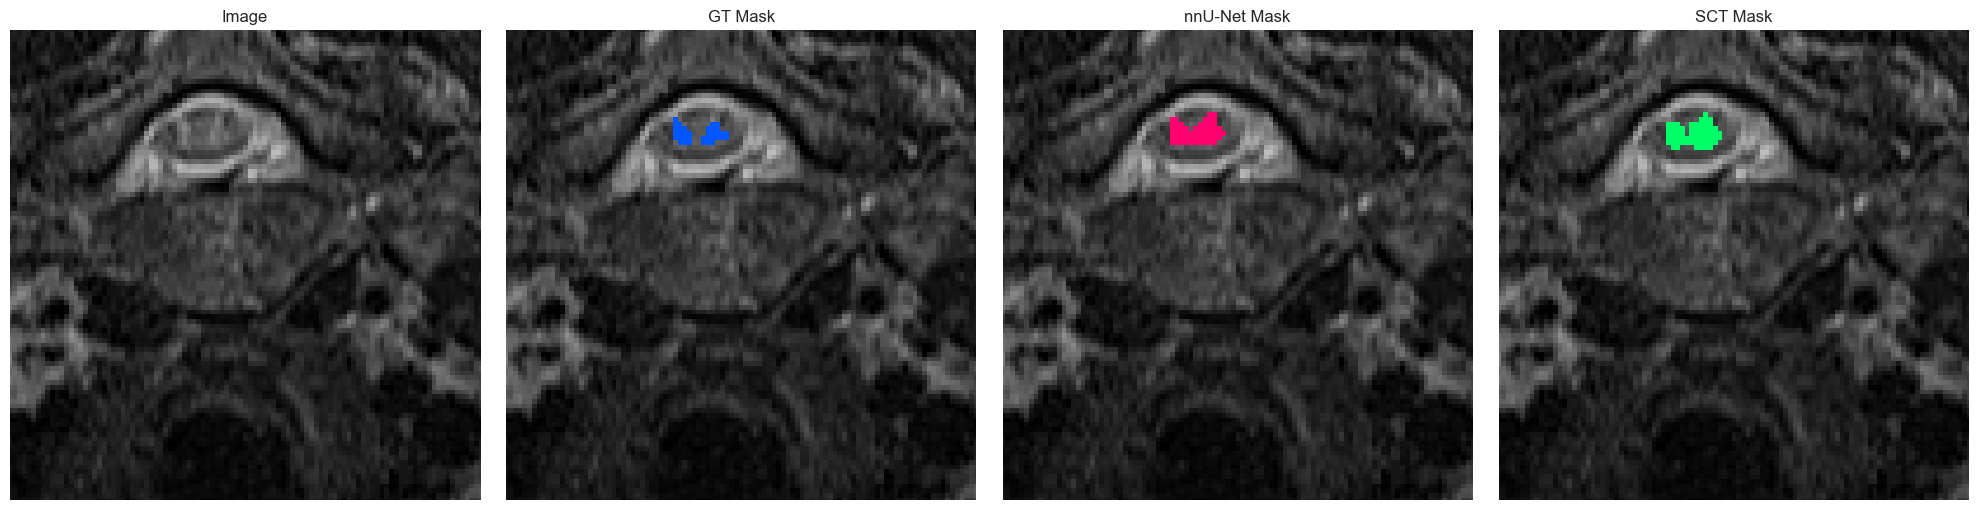

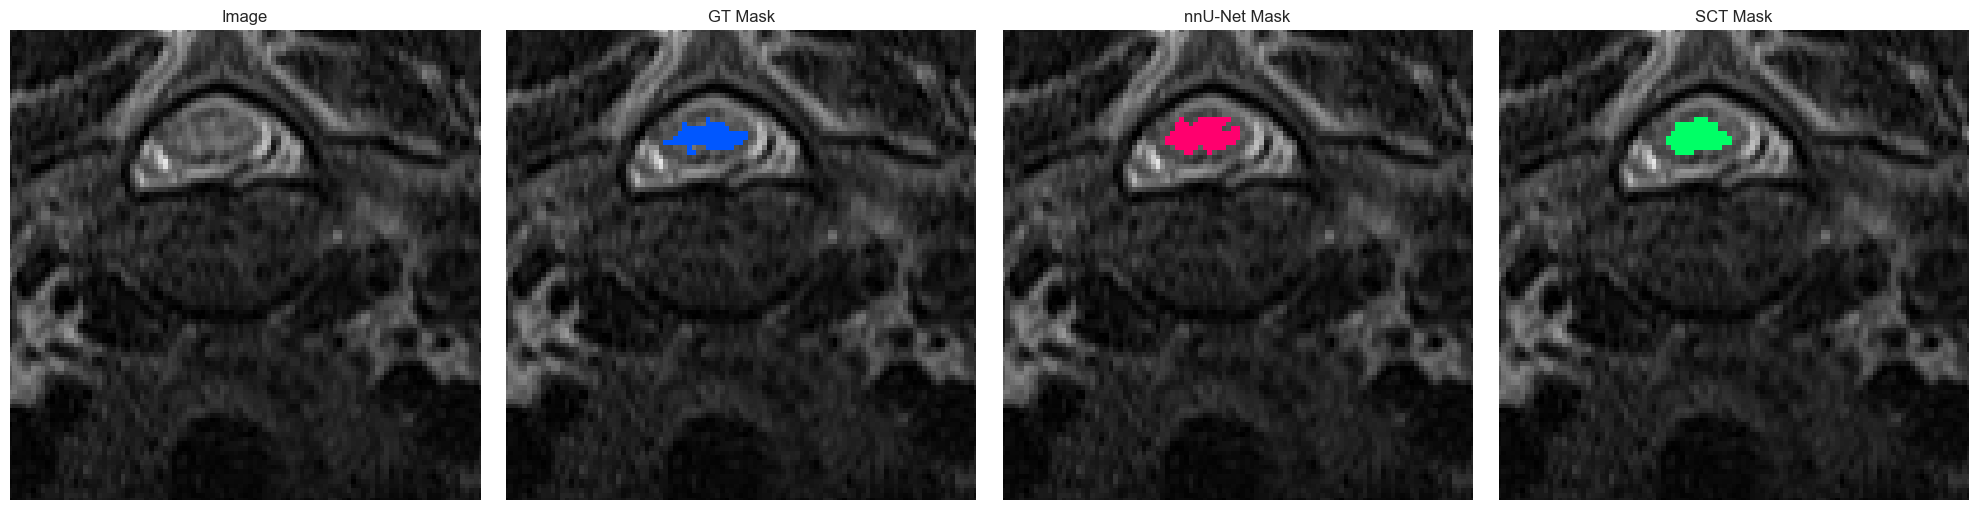

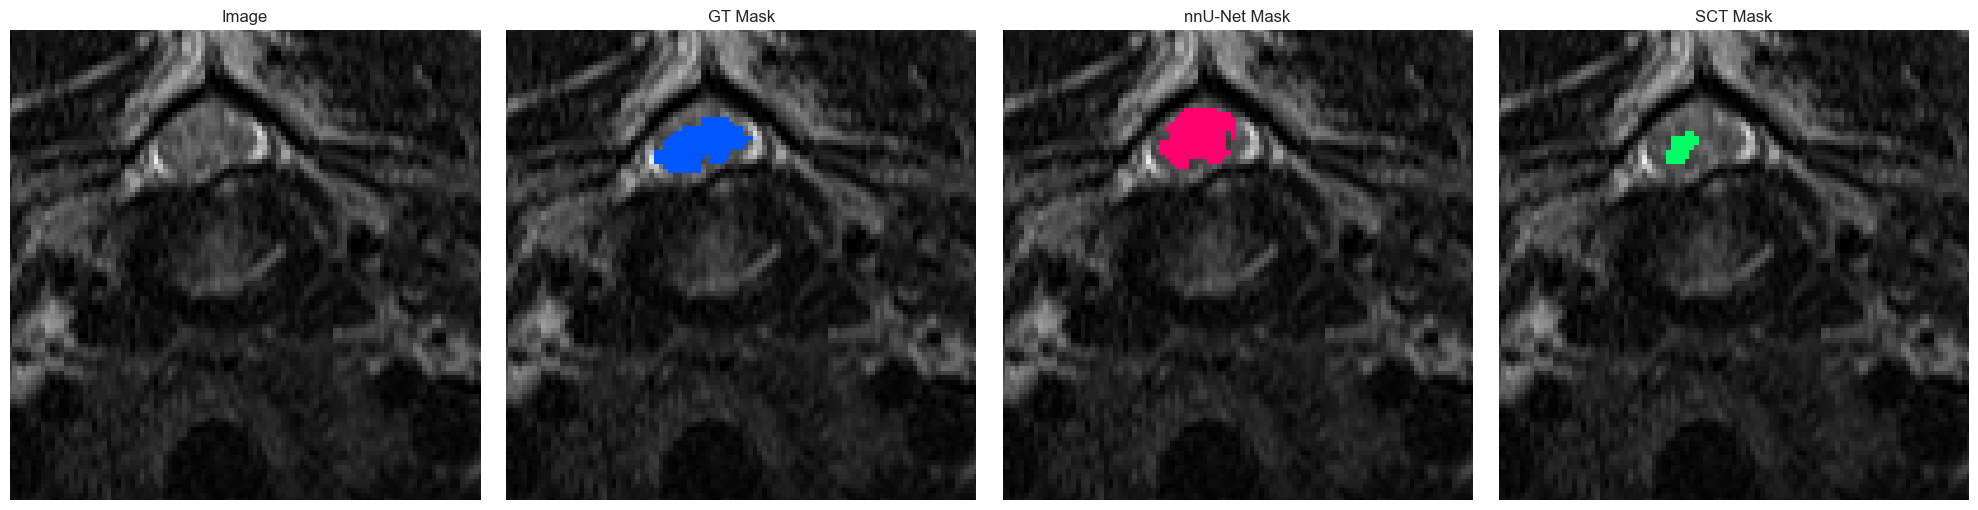

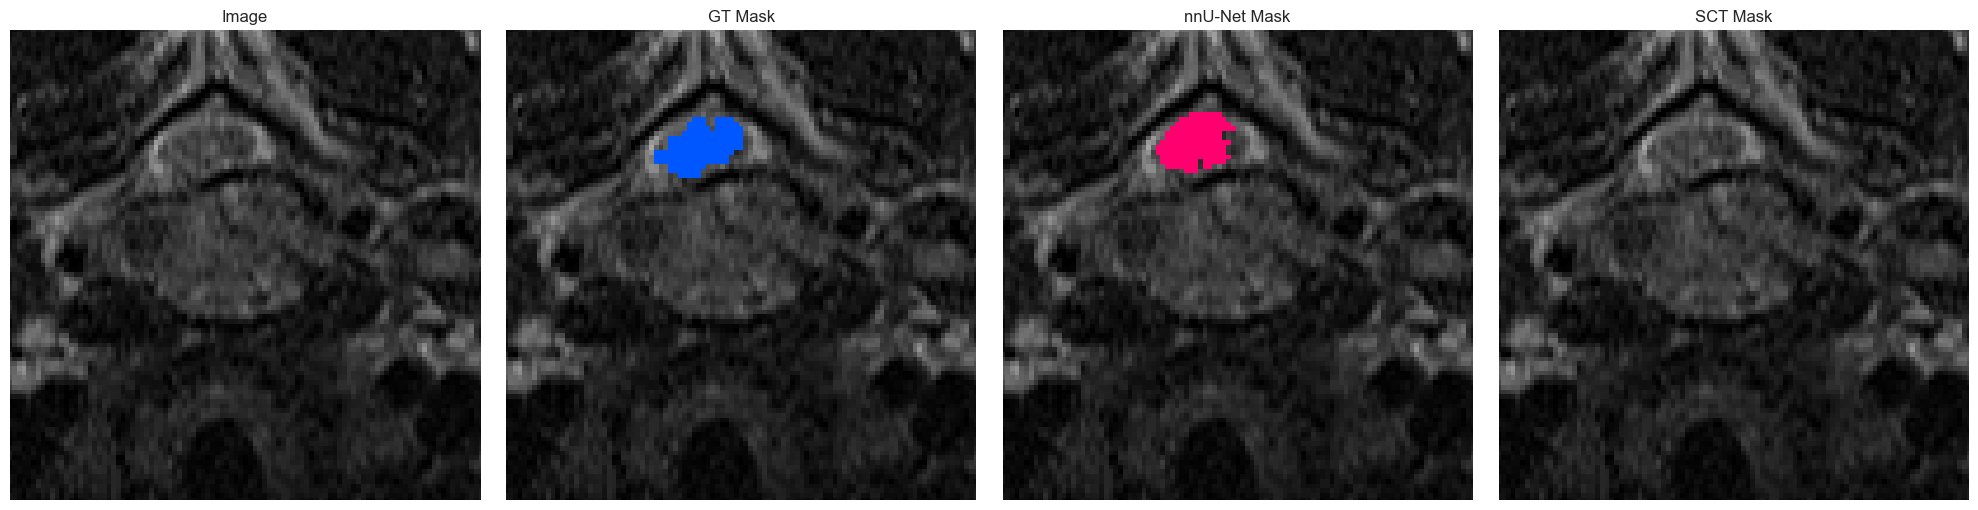

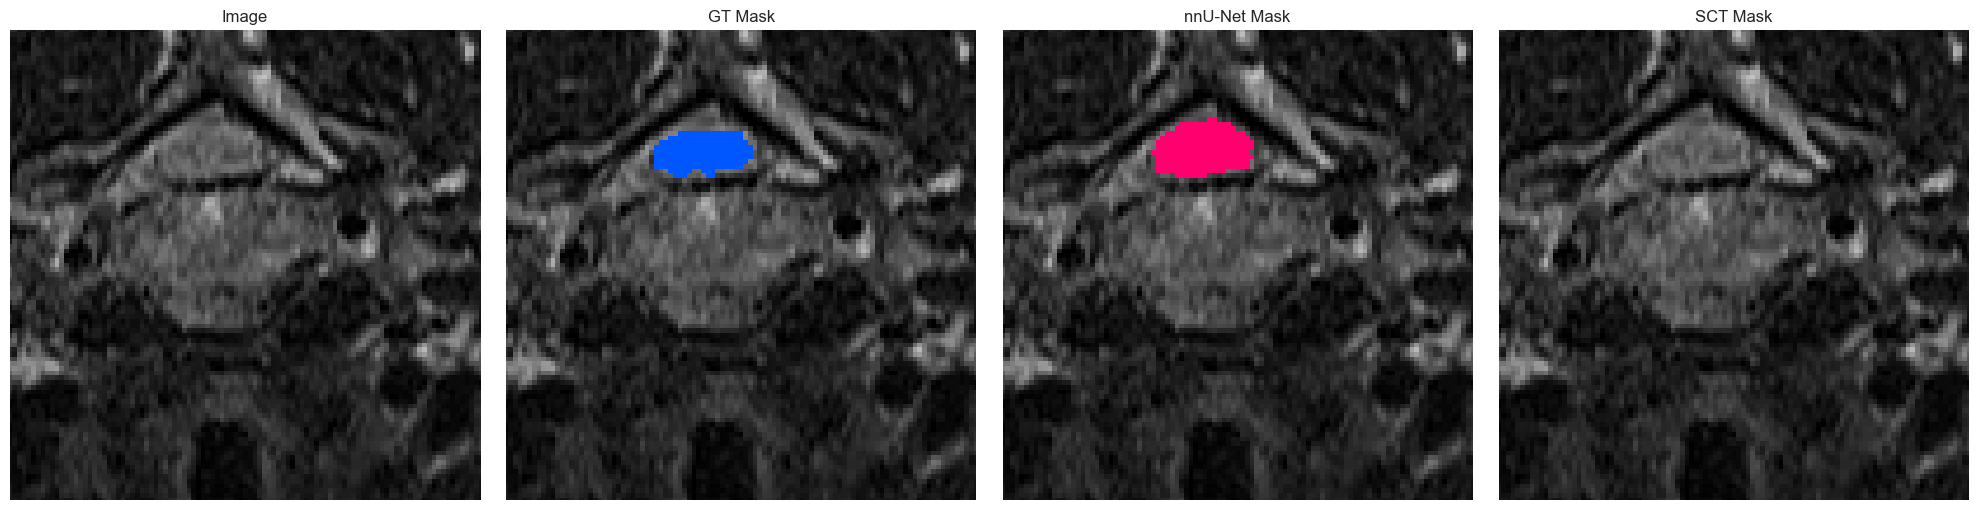

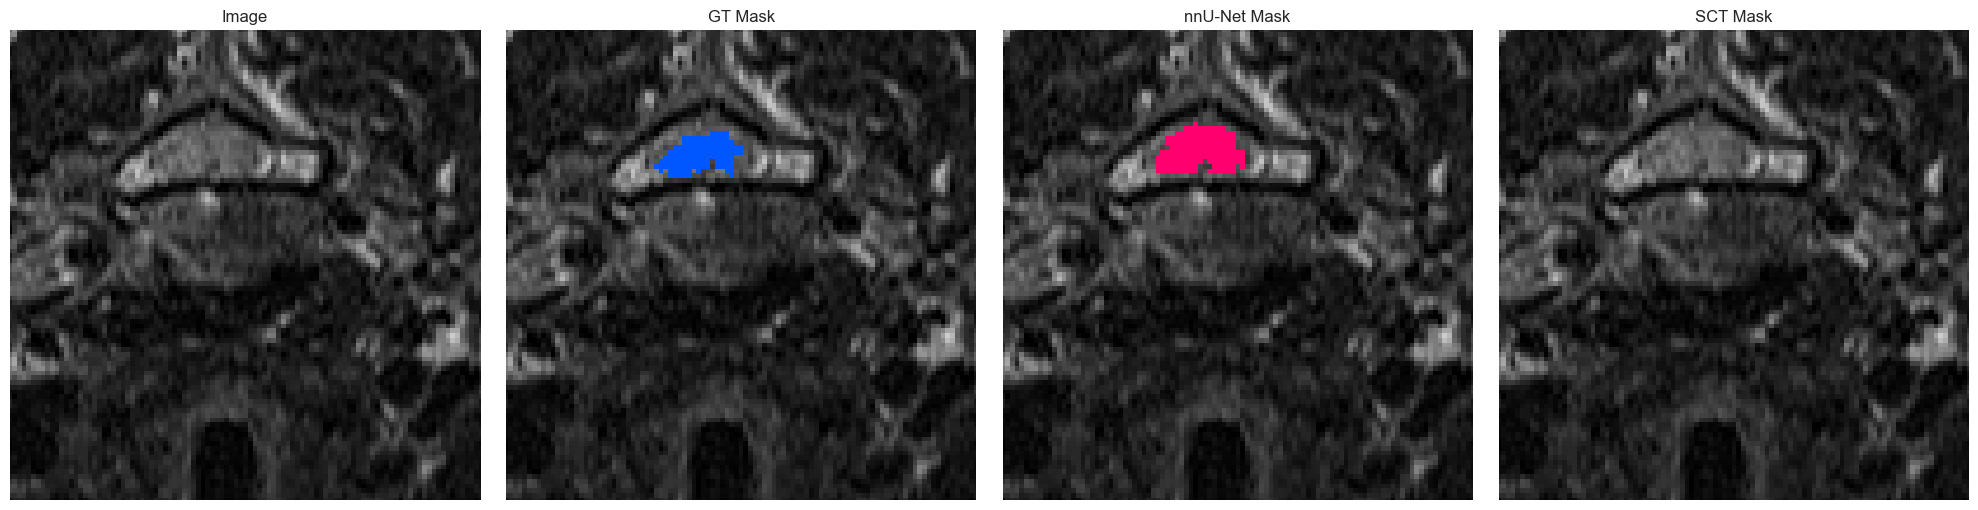

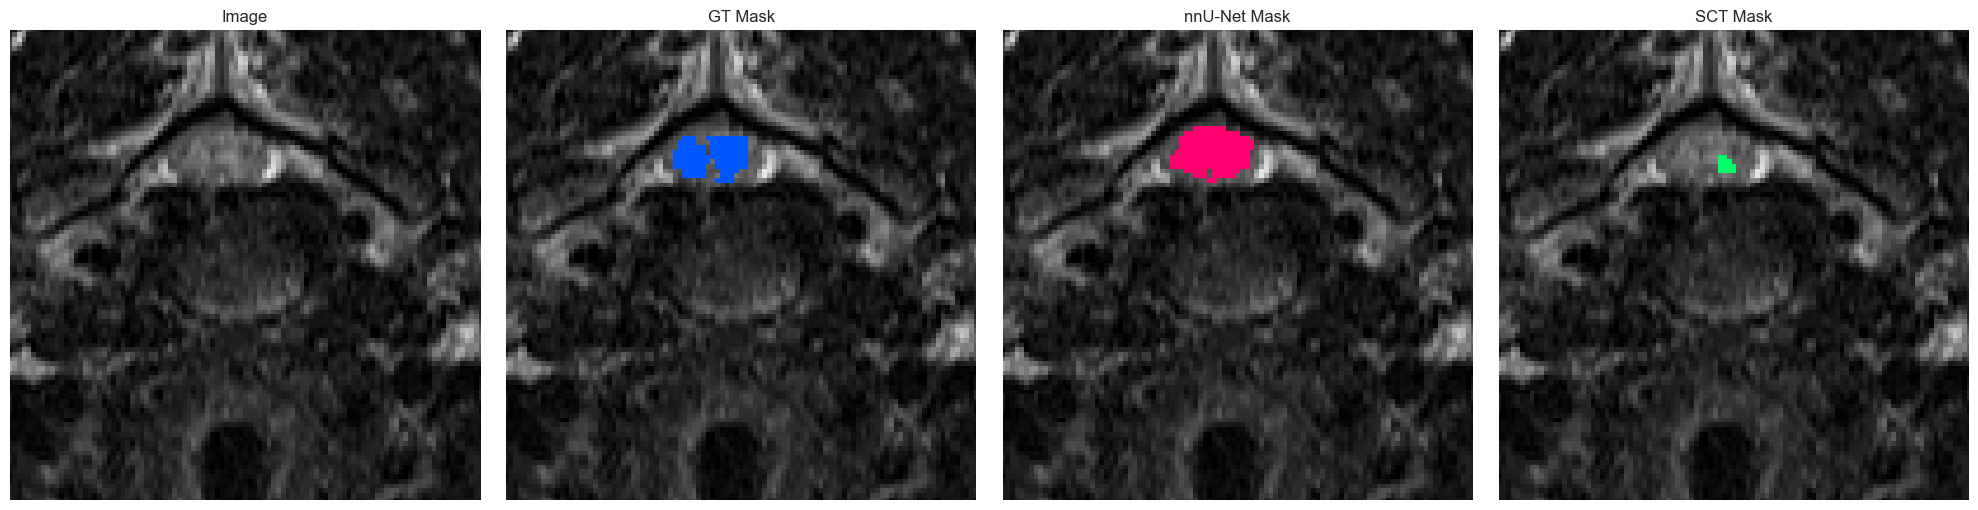

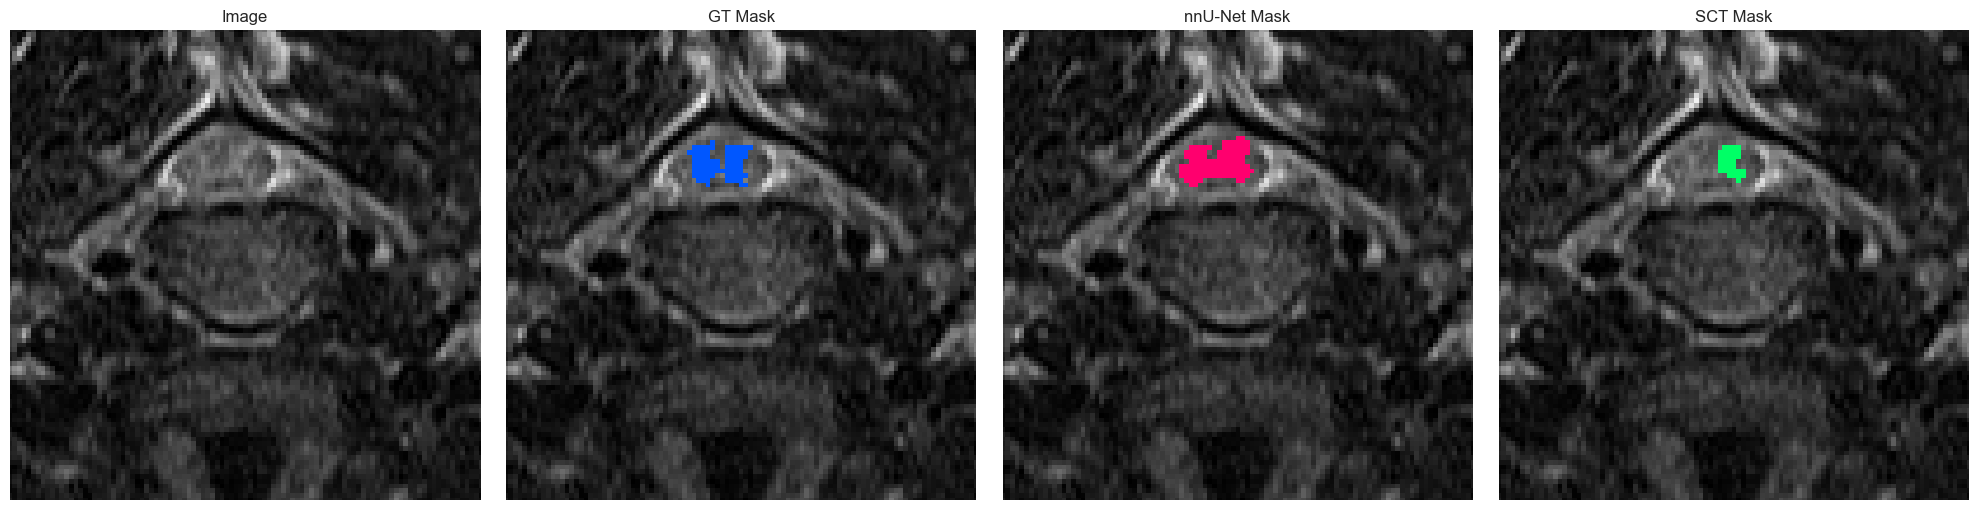

C:\Users\ortizo\IdeaProjects\BMEG_91_Q_project\.venv


In [16]:
# Load and visualize the images and the masks from the worst case and best case for each model

# helper function to select the highest axial slice and lowst axial slice that contains the mask
def get_mask_slices(mask):
    slices = np.where(mask.sum(axis=(0,1)) > 0)[0]
    if len(slices) == 0:
        return None, None
    return slices[0], slices[-1]

# helper function to select 10 slices that span the highest and lowest axial slice that contain the mask
def get_spanning_slices(mask, n_slices=12):
    z0, z1 = get_mask_slices(mask)
    if z0 is None or z1 is None:
        return []
    step = max((z1 - z0) // (n_slices - 1), 1)
    return list(range(z0, z1 + 1, step))[:n_slices]

# helper function to find the centroid of the mask in axial slice
def get_centroid(mask, slice_idx):
    # deal with empty masks
    ys, xs = np.where(mask[:, :, slice_idx] > 0)
    if len(ys) == 0 or len(xs) == 0:
        return None, None
    y_centroid = int(np.mean(ys))
    x_centroid = int(np.mean(xs))
    return y_centroid, x_centroid


# helper function tha takes the image, masks and slice indices and plots them in a row with the image, and the masks overlaid
def plot_slices(image, masks, mask_labels, slice_idx, mask_colors,name_slice):
    H, W, _ = image.shape

    # centroid in original coordinates
    y_centroid, x_centroid = get_centroid(masks[0], slice_idx)
    if y_centroid is None or x_centroid is None:
        print("No mask found in slice", slice_idx)
        y_centroid = H // 2
        x_centroid = W // 2

    # convert to rotated coordinates (k=1, 90° CCW)
    y_rot = x_centroid               # 0 .. W-1
    x_rot = H - 1 - y_centroid       # 0 .. H-1

    zoom_size = 100
    # note: x-range now uses [0, H), y-range uses [0, W)
    x_min = max(x_rot - zoom_size // 2, 0)
    x_max = min(x_rot + zoom_size // 2, H)
    y_min = max(y_rot - zoom_size // 2, 0)
    y_max = min(y_rot + zoom_size // 2, W)

    n_masks = len(masks)
    fig, axes = plt.subplots(1, n_masks + 1, figsize=(5 * (n_masks + 1), 5))

    # --- Base Image ---
    img = np.rot90(image[:, :, slice_idx])
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title("Image")
    axes[0].axis("off")
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_max, y_min)  # invert y-axis

    # --- Masks ---
    for i, (mask, label, color) in enumerate(zip(masks, mask_labels, mask_colors)):
        mask_slice = mask[:, :, slice_idx]
        masked = np.ma.masked_where(mask_slice == 0, mask_slice)

        cmap = ListedColormap([color])
        cmap.set_bad(alpha=0)

        axes[i + 1].imshow(img, cmap="gray")
        axes[i + 1].imshow(np.rot90(masked), cmap=cmap, alpha=1)
        axes[i + 1].set_title(label)
        axes[i + 1].axis("off")
        axes[i + 1].set_xlim(x_min, x_max)
        axes[i + 1].set_ylim(y_max, y_min)

    plt.tight_layout()

    # --- Save BEFORE show() ---
    saving_name = f"{name_slice}.png"
    plt.savefig(saving_name, dpi=300, bbox_inches="tight", transparent=False)

    plt.show()




# Set path to mri images
image_path = r"Z:\30_Oscar_Ortiz\15_SpineSeg\nnUnet\nnUNet_raw\Dataset730_SCIEMG\imagesTs"
image_ext = "_0001.nii.gz"
my_colors = ["#0057FF", "#FF006E", "#00FF66"]

# getting the worst and best cases for each model and plotting them
for model in models:
    sub_df = df[df["model"] == model]
    best_row = sub_df.loc[sub_df["f1"].idxmax()]
    worst_row = sub_df.loc[sub_df["f1"].idxmin()]
    for case, row in [("Best", best_row), ("Worst", worst_row)]:
        file_name = row["file_name"]
        print(f"Model: {model} | Case: {case} | File: {file_name}")
        # load image and masks
        # change the ending of fiel_name to match the image file
        image_file = os.path.join(image_path, file_name.replace(".nii.gz", image_ext))
        image_nib = nib.load(image_file)
        image_data = image_nib.get_fdata()
        gt_mask_nib = nib.load(os.path.join(path,gt_folder, file_name))
        nnunet_mask_nib = nib.load(os.path.join(path,nnunet_folder, file_name))
        sct_mask_nib = nib.load(os.path.join(path,sct_folder, file_name))
        # resample gt mask to image space
        gt_resampled_mask_nib = resample_to_img(
            gt_mask_nib,
            image_nib,
            interpolation="nearest",  # IMPORTANT for masks,
            force_resample=True,
            copy_header=True
        )
        gt_resampled_data = gt_resampled_mask_nib.get_fdata().astype(bool)
        nnunet_data = nnunet_mask_nib.get_fdata().astype(bool)
        sct_data = sct_mask_nib.get_fdata().astype(bool)
        # get spanning slices
        spanning_slices = get_spanning_slices(gt_resampled_data, n_slices=10)
        # get rid of extension in file name
        saving_name = file_name.replace('.nii.gz', '_')
        for slice_idx in spanning_slices:
            plot_slices(image_data,
                        [gt_resampled_data, nnunet_data, sct_data],
                        ["GT Mask", "nnU-Net Mask", "SCT Mask"],
                        slice_idx,
                        mask_colors = my_colors,
                        name_slice = f"{saving_name} {slice_idx}")
            # save the plot


# print working directory

print(os.getcwd())

File: SCIEMG_027.nii.gz
 Model: nnU-Net
  Dice: 0.660300136425648
  Jaccard: 0.49287169042769857
  Precision: 0.893
  Recall: 0.524
  F1: 0.66
  ASSD: 0.8508898053386723
  HD: 6.4031242374328485
  HD95: 2.5063303500776213
 Model: SCT
  Dice: 0.7095391211146839
  Jaccard: 0.5498338870431894
  Precision: 0.703
  Recall: 0.716
  F1: 0.709
  ASSD: 0.62821387509132
  HD: 4.242640687119285
  HD95: 1.4142135623730951


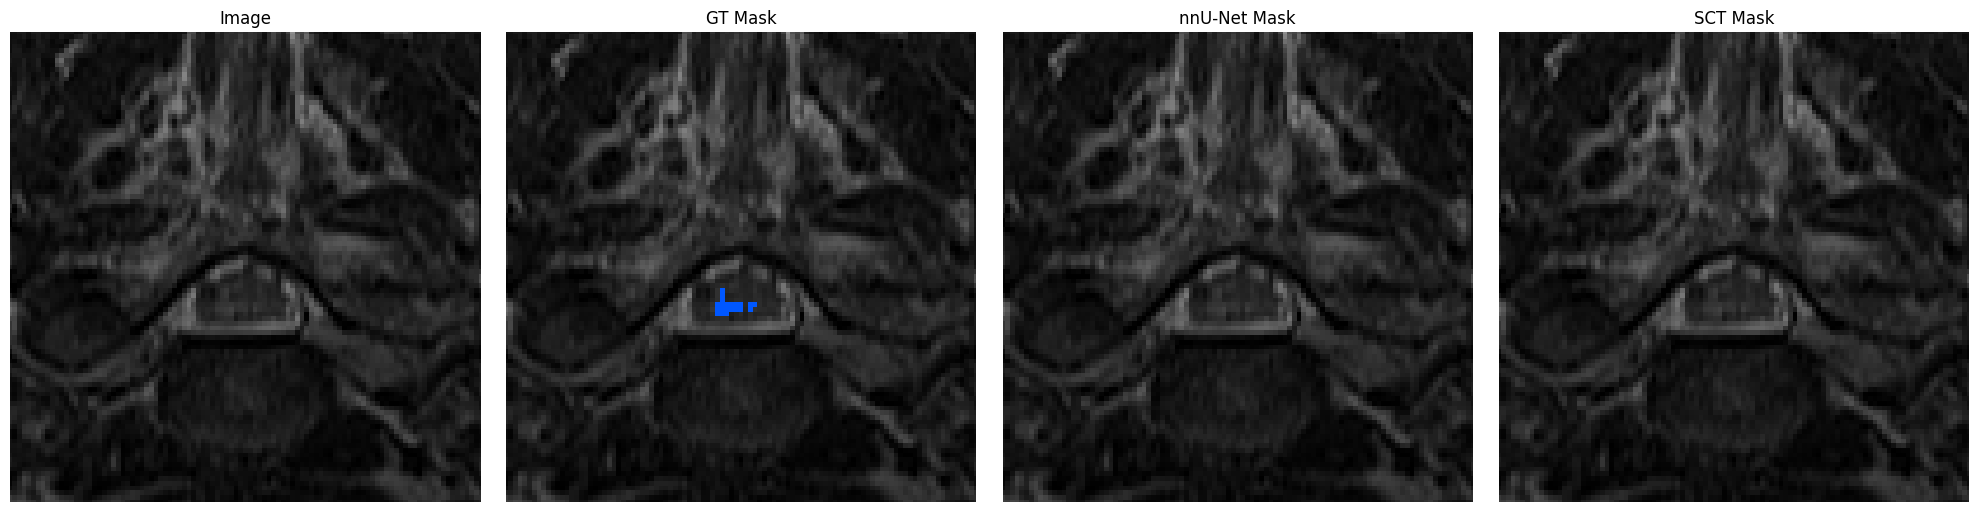

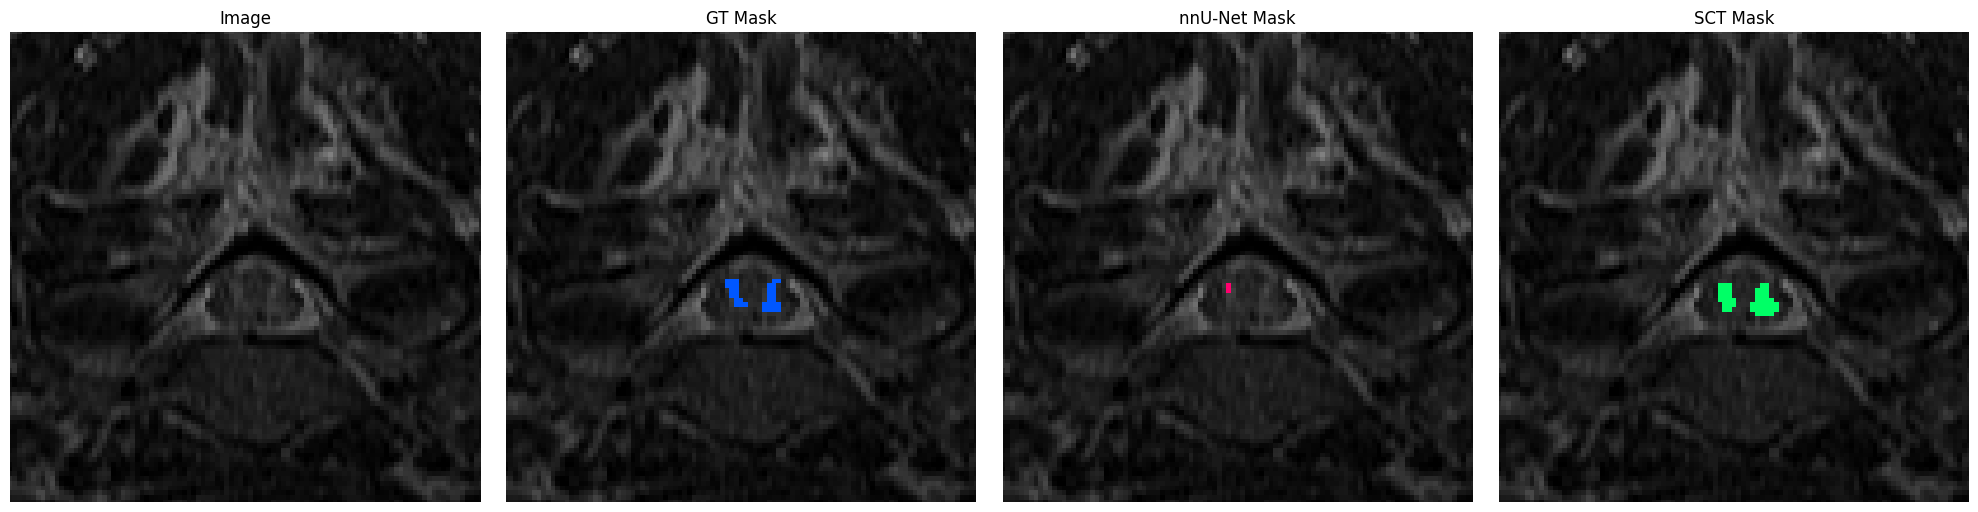

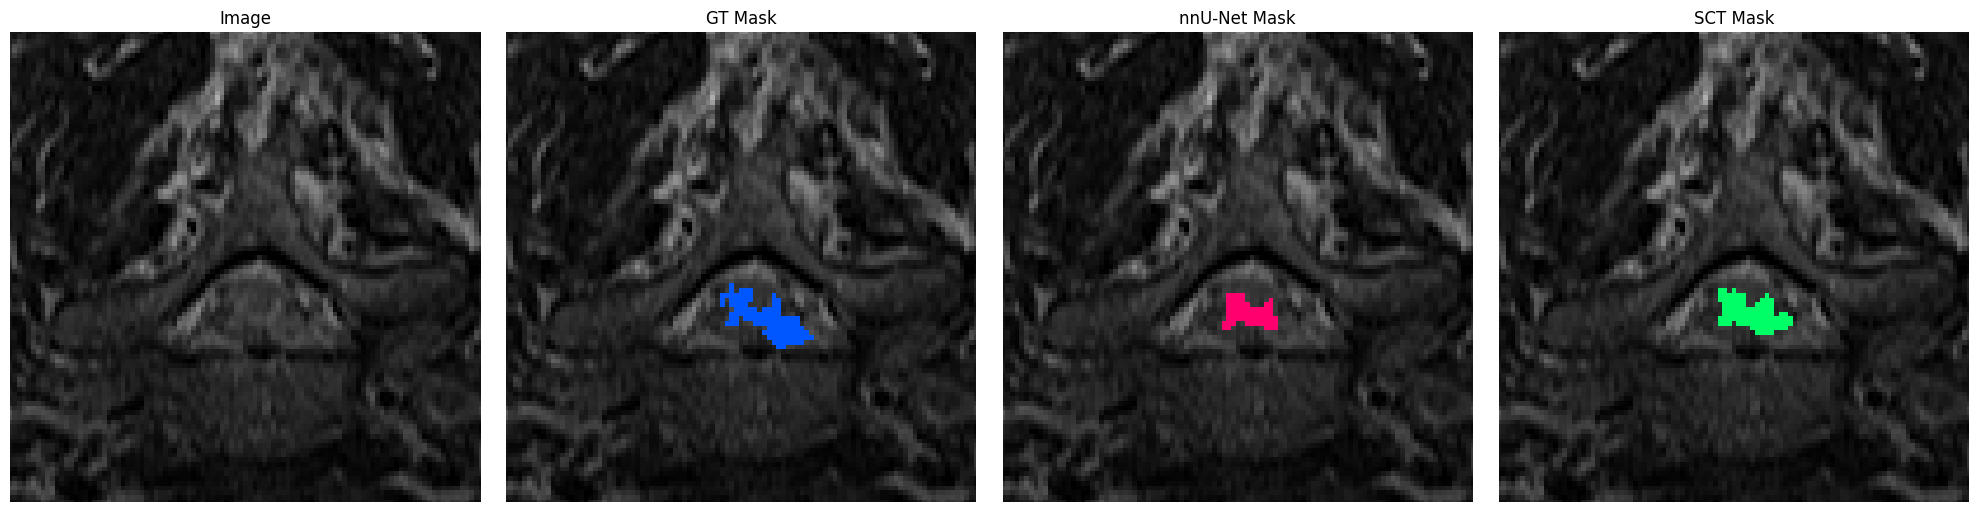

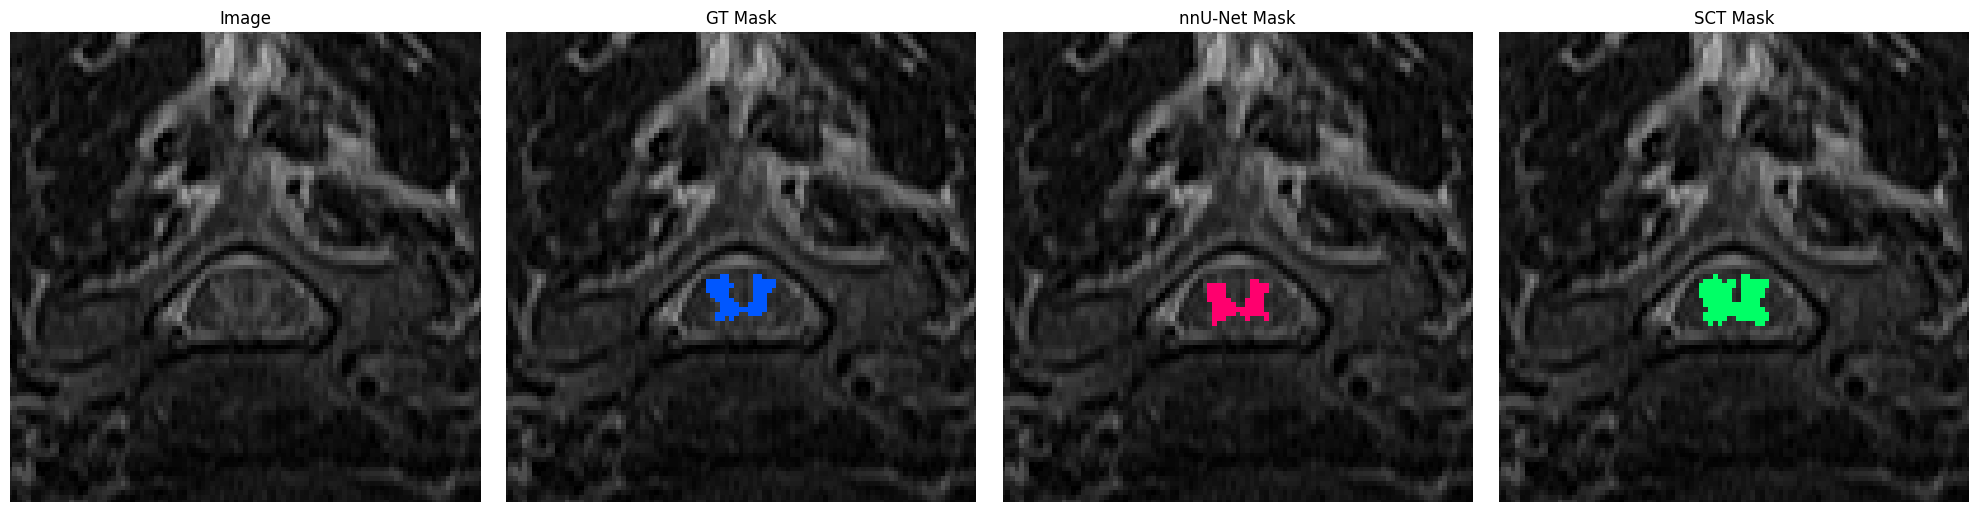

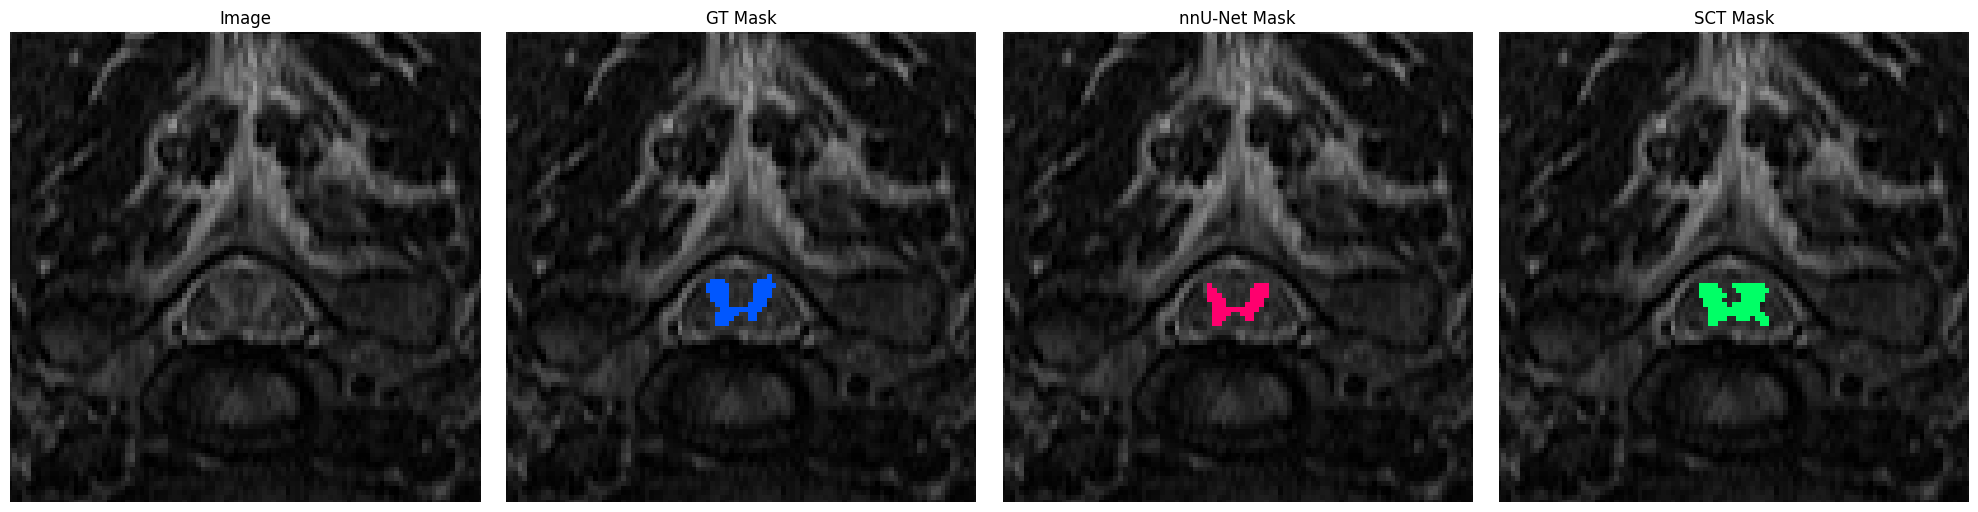

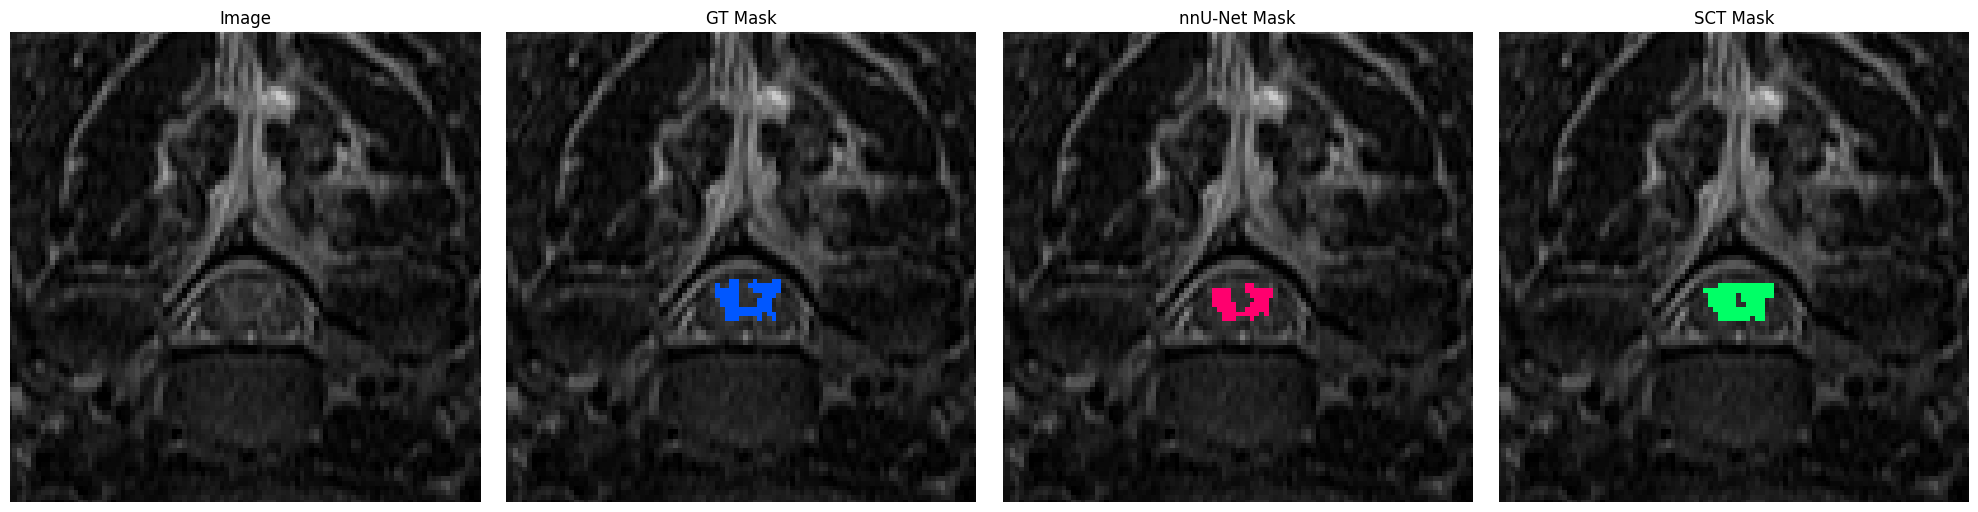

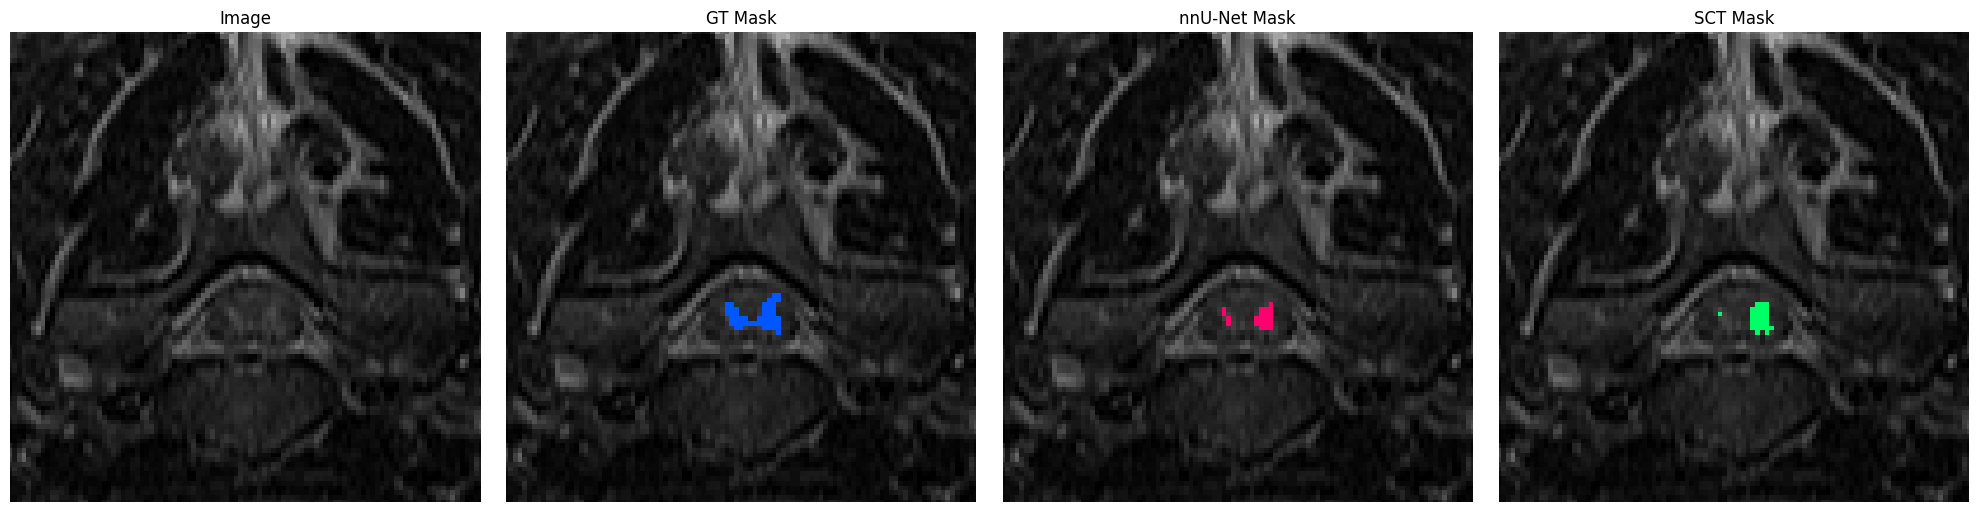

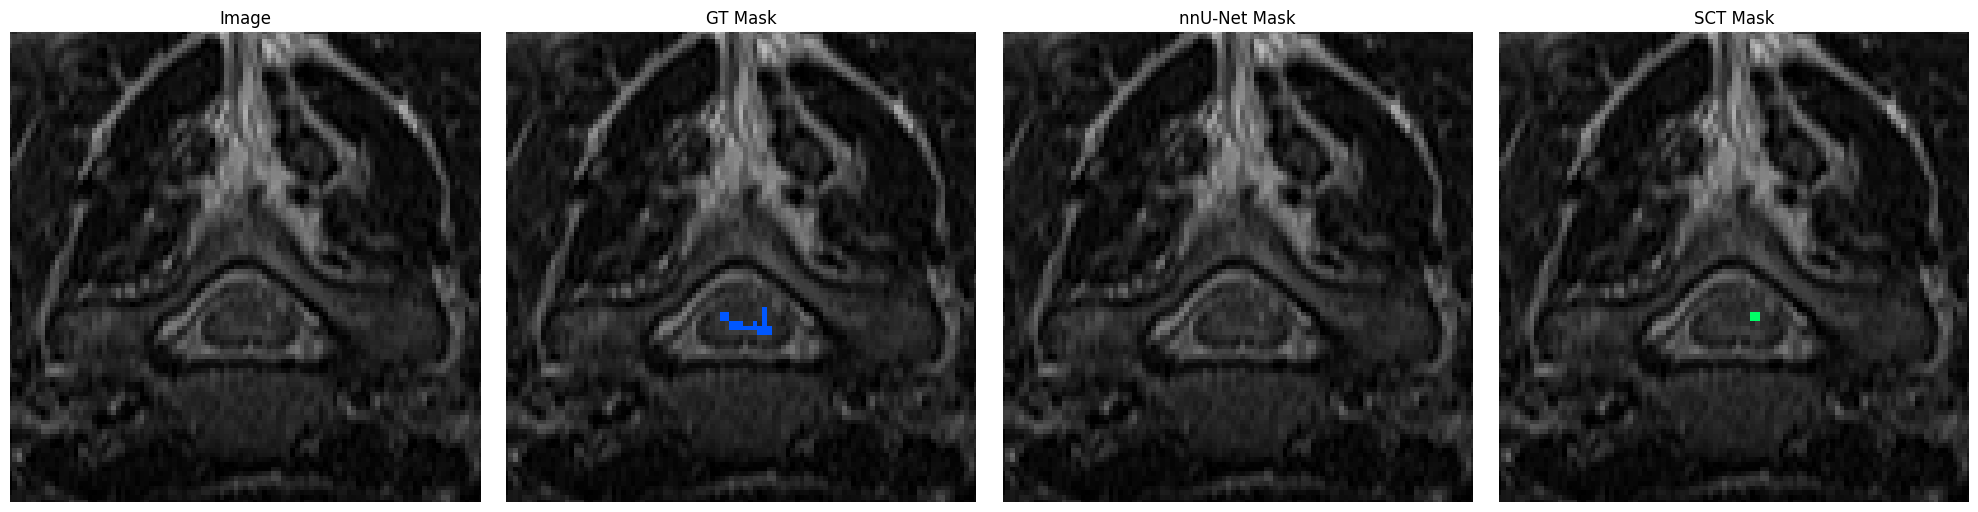

In [120]:
# selecting specific case to visualize
file_name = "SCIEMG_027.nii.gz"
print(f"File: {file_name}")
#print the metrics for this file
sub_df = df[df["file_name"] == file_name]
for index, row in sub_df.iterrows():
    print(f" Model: {row['model']}")
    print(f"  Dice: {row['dice']}")
    print(f"  Jaccard: {row['jaccard']}")
    print(f"  Precision: {row['precision']}")
    print(f"  Recall: {row['recall']}")
    print(f"  F1: {row['f1']}")
    print(f"  ASSD: {row['assd']}")
    print(f"  HD: {row['hd']}")
    print(f"  HD95: {row['hd95']}")

# load image and masks
# change the ending of fiel_name to match the image file
image_file = os.path.join(image_path, file_name.replace(".nii.gz", image_ext))
image_nib = nib.load(image_file)
image_data = image_nib.get_fdata()
gt_mask_nib = nib.load(os.path.join(path,gt_folder, file_name))
nnunet_mask_nib = nib.load(os.path.join(path,nnunet_folder, file_name))
sct_mask_nib = nib.load(os.path.join(path,sct_folder, file_name))
# resample gt mask to image space
gt_resampled_mask_nib = resample_to_img(
    gt_mask_nib,
    image_nib,
    interpolation="nearest",  # IMPORTANT for masks,
    force_resample=True,
    copy_header=True
)
gt_resampled_data = gt_resampled_mask_nib.get_fdata().astype(bool)
nnunet_data = nnunet_mask_nib.get_fdata().astype(bool)
sct_data = sct_mask_nib.get_fdata().astype(bool)
# get spanning slices
spanning_slices = get_spanning_slices(gt_resampled_data, n_slices=10)
for slice_idx in spanning_slices:
    plot_slices(image_data,
                [gt_resampled_data, nnunet_data, sct_data],
                ["GT Mask", "nnU-Net Mask", "SCT Mask"],
                slice_idx,
                mask_colors = my_colors)

Running some statistics

In [121]:
# perform statistical tests to compare the models
from scipy.stats import wilcoxon
metrics = ["dice", "jaccard", "precision", "recall", "f1", "assd", "hd", "hd95"]
for metric in metrics:
    nnunet_values = df[df["model"] == "nnU-Net"][metric]
    sct_values = df[df["model"] == "SCT"][metric]
    stat, p = wilcoxon(nnunet_values, sct_values)
    print(f"Metric: {metric} | Wilcoxon stat={stat:.4f} | p-value={p:.4f}")

Metric: dice | Wilcoxon stat=2.0000 | p-value=0.0117
Metric: jaccard | Wilcoxon stat=2.0000 | p-value=0.0117
Metric: precision | Wilcoxon stat=22.0000 | p-value=1.0000
Metric: recall | Wilcoxon stat=3.0000 | p-value=0.0195
Metric: f1 | Wilcoxon stat=2.0000 | p-value=0.0117
Metric: assd | Wilcoxon stat=2.0000 | p-value=0.0117
Metric: hd | Wilcoxon stat=10.0000 | p-value=0.1641
Metric: hd95 | Wilcoxon stat=3.0000 | p-value=0.0391


In [22]:
# --------- your original brightness & contrast ---------
def image_contrast(image):
    # compute contrast as the std of the image intensities
    return float(np.std(image))


def image_brightness(image):
    # compute brightness as the mean of the image intensities
    return float(np.mean(image))


# --------- extra image-quality features ---------
def _get_middle_slice(image):
    """
    Get a 2D middle slice for 3D volumes.
    Assumes shape (H, W, D) or (D, H, W); adjust if needed.
    Here we treat the last axis as depth.
    """
    if image.ndim == 3:
        mid = image.shape[-1] // 2
        sl = image[..., mid]
    else:
        sl = image  # already 2D
    return sl


def compute_all_features(image):
    """
    image: numpy array from nib.load(...).get_fdata()
    Returns a dict of all features for one volume.
    """

    image = np.asarray(image, dtype=np.float32)

    feats = {}

    # --- brightness & contrast on full volume ---
    feats["brightness"] = image_brightness(image)
    feats["contrast"] = image_contrast(image)

    # --- middle slice for 2D-based features ---
    sl = _get_middle_slice(image)
    sl_norm = sl - sl.min()
    denom = sl_norm.max() - sl_norm.min() + 1e-8
    sl_norm = sl_norm / denom  # normalize to ~[0, 1]

    # --- sharpness: variance of Laplacian on slice ---
    lap = laplace(sl_norm)
    feats["sharpness_lap"] = float(lap.var())

    # --- noise_std & SNR on full volume (high-frequency component) ---
    smooth = gaussian_filter(image, sigma=1.0)
    high_freq = image - smooth
    feats["noise_std"] = float(high_freq.std())
    feats["snr"] = float(feats["brightness"] / (feats["noise_std"] + 1e-8))

    # --- edge density (Canny) on slice ---
    edges = canny(sl_norm, sigma=1.0)
    feats["edge_density"] = float(edges.mean())  # fraction of edge pixels

    # --- entropy on slice ---
    feats["entropy"] = float(shannon_entropy(sl_norm))

    # --- GLCM texture features on slice ---
    levels = 8
    sl_u8 = img_as_ubyte(sl_norm)
    quantized = (sl_u8 * levels / 256).astype(np.uint8)

    glcm = graycomatrix(
        quantized,
        distances=[1],
        angles=[0],
        levels=levels,
        symmetric=True,
        normed=True,
    )

    feats["glcm_contrast"] = float(graycoprops(glcm, "contrast")[0, 0])
    feats["glcm_homogeneity"] = float(graycoprops(glcm, "homogeneity")[0, 0])
    feats["glcm_energy"] = float(graycoprops(glcm, "energy")[0, 0])
    feats["glcm_correlation"] = float(graycoprops(glcm, "correlation")[0, 0])

    return feats


# --------- main loop: load NIfTI, compute ALL features once ---------
brightness_list = []
contrast_list = []
sharpness_list = []
noise_std_list = []
snr_list = []
edge_density_list = []
entropy_list = []
glcm_contrast_list = []
glcm_homog_list = []
glcm_energy_list = []
glcm_corr_list = []
dice_list = []   # you already have this in df but we keep it for clarity

for index, row in df.iterrows():
    file_name = row["file_name"]

    # load image
    image_file = os.path.join(image_path, file_name.replace(".nii.gz", image_ext))
    image_nib = nib.load(image_file)
    image_data = image_nib.get_fdata()

    # compute all features
    feats = compute_all_features(image_data)

    brightness_list.append(feats["brightness"])
    contrast_list.append(feats["contrast"])
    sharpness_list.append(feats["sharpness_lap"])
    noise_std_list.append(feats["noise_std"])
    snr_list.append(feats["snr"])
    edge_density_list.append(feats["edge_density"])
    entropy_list.append(feats["entropy"])
    glcm_contrast_list.append(feats["glcm_contrast"])
    glcm_homog_list.append(feats["glcm_homogeneity"])
    glcm_energy_list.append(feats["glcm_energy"])
    glcm_corr_list.append(feats["glcm_correlation"])

    dice_list.append(row["dice"])


# --------- add to dataframe ---------
df["brightness"] = brightness_list
df["contrast"] = contrast_list
df["sharpness_lap"] = sharpness_list
df["noise_std"] = noise_std_list
df["snr"] = snr_list
df["edge_density"] = edge_density_list
df["entropy"] = entropy_list
df["glcm_contrast"] = glcm_contrast_list
df["glcm_homogeneity"] = glcm_homog_list
df["glcm_energy"] = glcm_energy_list
df["glcm_correlation"] = glcm_corr_list

# (dice is already in df, so we don't need to reassign dice_list)


# --------- compute correlations with Dice for all features ---------
features = [
    "brightness",
    "contrast",
    "sharpness_lap",
    "noise_std",
    "snr",
    "edge_density",
    "entropy",
    "glcm_contrast",
    "glcm_homogeneity",
    "glcm_energy",
    "glcm_correlation",
]

for model in models:
    sub_df = df[df["model"] == model]
    print(f"\nModel: {model}")
    for feat in features:
        corr = np.corrcoef(sub_df[feat], sub_df["dice"])[0, 1]
        print(f"  {feat}-Dice Corr: {corr:.4f}")



Model: nnU-Net
  brightness-Dice Corr: -0.1294
  contrast-Dice Corr: -0.1394
  sharpness_lap-Dice Corr: -0.1279
  noise_std-Dice Corr: -0.2433
  snr-Dice Corr: 0.1791
  edge_density-Dice Corr: -0.1078
  entropy-Dice Corr: -0.1970
  glcm_contrast-Dice Corr: nan
  glcm_homogeneity-Dice Corr: nan
  glcm_energy-Dice Corr: nan
  glcm_correlation-Dice Corr: nan

Model: SCT
  brightness-Dice Corr: 0.5389
  contrast-Dice Corr: 0.6187
  sharpness_lap-Dice Corr: 0.0490
  noise_std-Dice Corr: 0.3512
  snr-Dice Corr: 0.6672
  edge_density-Dice Corr: -0.0929
  entropy-Dice Corr: 0.1198
  glcm_contrast-Dice Corr: nan
  glcm_homogeneity-Dice Corr: nan
  glcm_energy-Dice Corr: nan
  glcm_correlation-Dice Corr: nan


C:\Users\ortizo\IdeaProjects\BMEG_91_Q_project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ortizo\IdeaProjects\BMEG_91_Q_project\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


<Figure size 1500x1200 with 0 Axes>

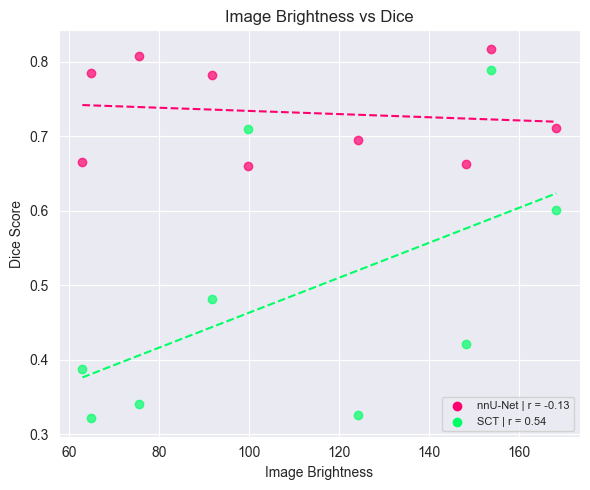

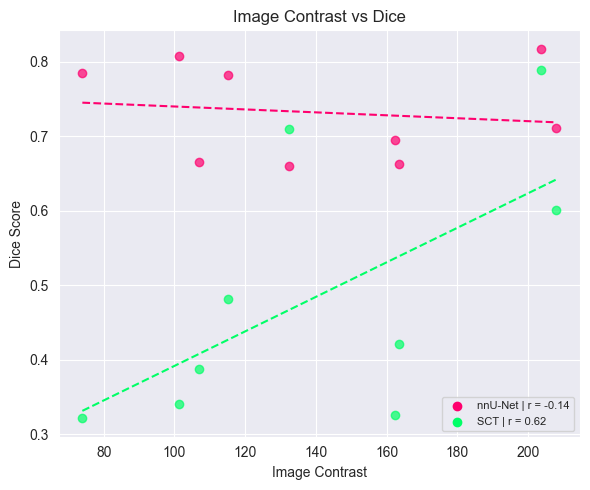

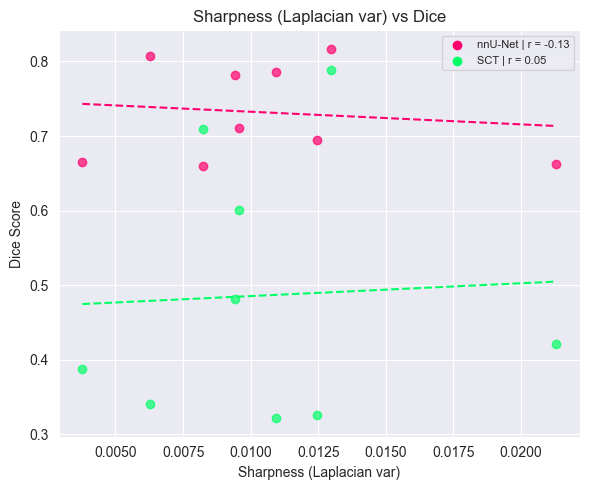

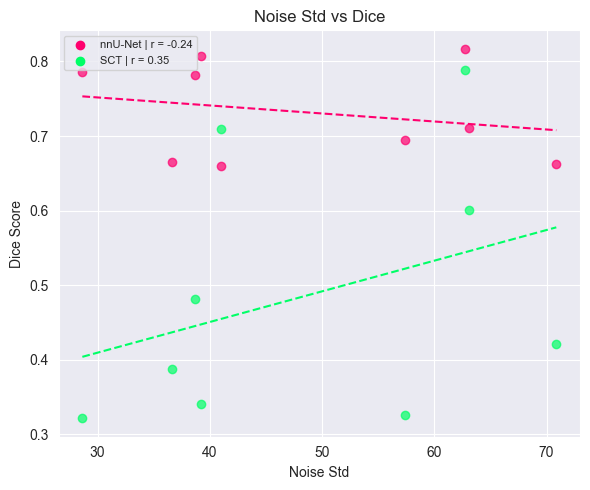

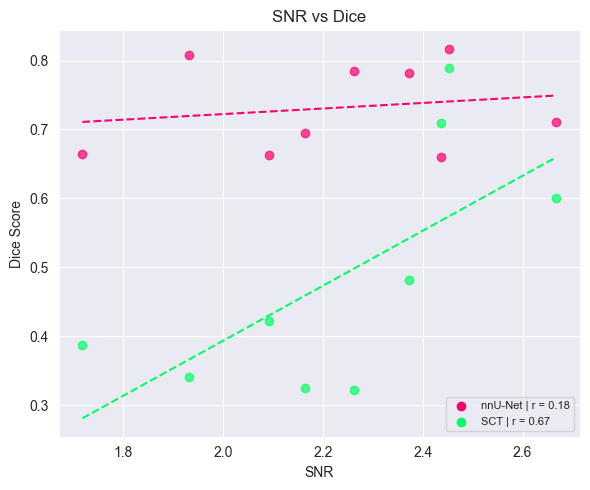

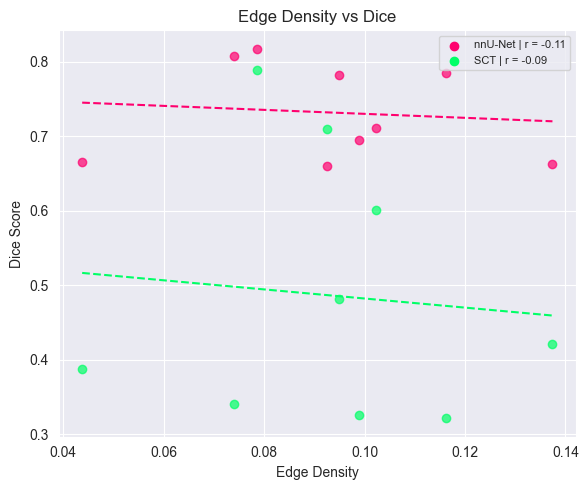

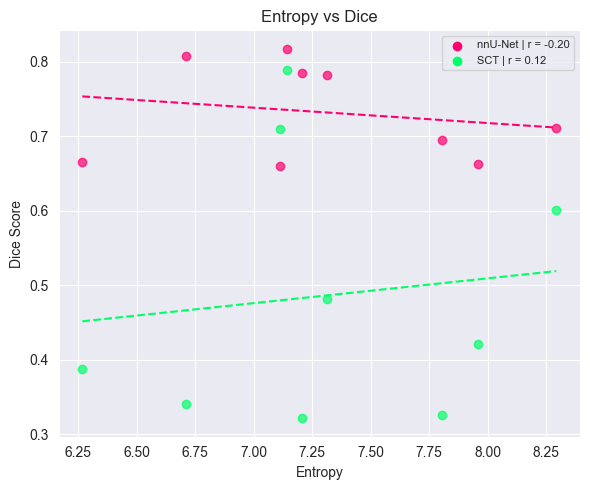

In [23]:

# Define hex colors for each model

# Define hex colors for each model
colors = {
    "nnU-Net": "#FF006E",
    "SCT": "#00FF66",
    # add more if needed
}

# List of all metrics you want to correlate with Dice
# (make sure these column names exist in df)
metrics = [
    ("brightness",        "Image Brightness"),
    ("contrast",          "Image Contrast"),
    ("sharpness_lap",     "Sharpness (Laplacian var)"),
    ("noise_std",         "Noise Std"),
    ("snr",               "SNR"),
    ("edge_density",      "Edge Density"),
    ("entropy",           "Entropy")
]

n_metrics = len(metrics)
n_cols = 3  # how many plots per row
n_rows = int(np.ceil(n_metrics / n_cols))

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for feat_name, pretty_label in metrics:

    plt.figure(figsize=(6, 5))   # create a NEW figure for each metric

    for model in models:
        sub_df = df[df["model"] == model].dropna(subset=[feat_name, "dice"])
        if sub_df.empty:
            continue

        x = sub_df[feat_name].values
        y = sub_df["dice"].values

        color = colors.get(model, "#333333")

        # Scatter
        plt.scatter(x, y, color=color, alpha=0.7)

        # Trendline if enough points
        if len(sub_df) > 1:
            z = np.polyfit(x, y, 1)
            p = np.poly1d(z)
            xs = np.linspace(x.min(), x.max(), 100)
            plt.plot(xs, p(xs), "--", color=color)

            # Correlation
            r, _ = pearsonr(x, y)
            legend_label = f"{model} | r = {r:.2f}"
        else:
            legend_label = f"{model} | n={len(sub_df)}"

        # Dummy entry for legend
        plt.scatter([], [], color=color, label=legend_label)

    plt.xlabel(pretty_label)
    plt.ylabel("Dice Score")
    plt.title(f"{pretty_label} vs Dice")
    plt.legend(fontsize=8)
    plt.tight_layout()

    # OPTIONAL: Save each figure using the feature name
    plt.savefig(f"{feat_name}_vs_dice.png", dpi=300, bbox_inches="tight")

    plt.show()

    plt.close()    # prevents figure stacking


In [139]:
# other image properties here
# ---- Helper: load as grayscale in [0, 1] ----
def load_gray(path):
    img = io.imread(path)
    if img.ndim == 3:  # RGB or RGBA
        img = img[..., :3]  # drop alpha if present
        gray = color.rgb2gray(img)
    else:
        gray = img.astype(np.float32)
        # normalize if it looks like 0–255
        if gray.max() > 1.5:
            gray = gray / 255.0
    return gray


# ---- Sharpness (variance of Laplacian) ----
def sharpness_variance_of_laplacian(gray):
    # cv2 expects 0–255 uint8
    gray_u8 = img_as_ubyte(gray)
    lap = cv2.Laplacian(gray_u8, cv2.CV_64F)
    return float(lap.var())


# ---- Noise estimate (std of high-frequency component) ----
def noise_std(gray, sigma=1.0):
    blurred = filters.gaussian(gray, sigma=sigma)
    high_freq = gray - blurred
    return float(high_freq.std())


# ---- SNR (mean / noise_std) ----
def snr(gray, noise_sigma=1.0):
    n = noise_std(gray, sigma=noise_sigma)
    return float(gray.mean() / (n + 1e-8))


# ---- Edge density (fraction of edge pixels) ----
def edge_density(gray, sigma=1.0):
    edges = canny(gray, sigma=sigma)
    return float(edges.mean())  # True counts as 1 → proportion of edge pixels


# ---- Entropy ----
def image_entropy(gray):
    return float(shannon_entropy(gray))


# ---- GLCM texture features ----
def glcm_features(gray, levels=8, distance=1, angle=0):
    # quantize to a small number of levels to keep GLCM stable
    gray_u8 = img_as_ubyte(gray)
    quantized = (gray_u8 * levels / 256).astype(np.uint8)
    glcm = graycomatrix(
        quantized,
        distances=[distance],
        angles=[angle],
        levels=levels,
        symmetric=True,
        normed=True,
    )

    contrast = float(graycoprops(glcm, "contrast")[0, 0])
    homogeneity = float(graycoprops(glcm, "homogeneity")[0, 0])
    energy = float(graycoprops(glcm, "energy")[0, 0])
    correlation = float(graycoprops(glcm, "correlation")[0, 0])

    return contrast, homogeneity, energy, correlation


# ---- Master function: compute all features for one image ----
def compute_image_features(path):
    gray = load_gray(path)

    feat = {}
    feat["sharpness_lap"] = sharpness_variance_of_laplacian(gray)
    feat["noise_std"] = noise_std(gray)
    feat["snr"] = snr(gray)
    feat["edge_density"] = edge_density(gray)
    feat["entropy"] = image_entropy(gray)

    glcm_contrast, glcm_homog, glcm_energy, glcm_corr = glcm_features(gray)
    feat["glcm_contrast"] = glcm_contrast
    feat["glcm_homogeneity"] = glcm_homog
    feat["glcm_energy"] = glcm_energy
    feat["glcm_correlation"] = glcm_corr

    return feat


# ---- Compute features for all images ----
image_features = []
for index, row in df.iterrows():
    file_name = row["file_name"]
    # load image
    image_file = os.path.join(image_path, file_name.replace(".nii.gz", image_ext))
    feats = compute_image_features(image_file)
    feats["file_name"] = file_name
    image_features.append(feats)


OSError: Could not find a backend to open `Z:\30_Oscar_Ortiz\15_SpineSeg\nnUnet\nnUNet_raw\Dataset730_SCIEMG\imagesTs\SCIEMG_012_0001.nii.gz`` with iomode `r`.